Make by Sofyan Gio Verdiansyah | Junior Data Scientist

# Download Datasets dari Kaggle<br>
Nama Datasets: HR Analytics Dataset<br>
Link: https://www.kaggle.com/datasets/hopesb/hr-analytics-dataset?select=Messy_HR_Dataset_Detailed.csv

### Penjelasan khasus pada Datasets (menurut saya)<br>
Pada kasus ini, kita dihadapkan pada tantangan untuk memprediksi status karyawan apakah akan tetap Aktif atau menjadi Non-Aktif (resign, pensiun, atau diberhentikan) di masa depan, berdasarkan profil dan rekam jejak mereka.

__Isi Dataset__<br>
Dataset ini memuat 3.150 data karyawan dengan 39 fitur yang mencakup berbagai aspek penting dalam Human Resource (HR), mulai dari data pribadi, informasi pekerjaan, status kepegawaian, kinerja dan kepuasan, hingga detail pelatihan yang pernah diikuti oleh karyawan.

Beberapa kategori data yang tersedia antara lain:
- __Informasi Demografis__: Nama, Tanggal Lahir, Gender, Ras, Status Pernikahan, dan Lokasi.
- __Detail Pekerjaan: Jabatan__, Divisi, Departemen, Business Unit, serta klasifikasi tipe karyawan.
- __Status Karyawan__: Aktif/Non-Aktif, termasuk detail penyebab terminasi (resign, pensiun, dll).
- __Kinerja dan Kepuasan__: Skor keterlibatan, kepuasan, work-life balance, serta skor performa.
- __Data Pelatihan__: Program pelatihan yang diikuti, hasil pelatihan, durasi, biaya pelatihan, dan trainer.

__Tujuan Analisis__<br>
Dataset ini dapat dimanfaatkan untuk membangun model prediksi guna:
- Mengantisipasi risiko turnover.
-Mengidentifikasi karyawan yang berpotensi resign atau diberhentikan, sebelum hal itu terjadi.
- Memberikan insight bagi tim HR agar bisa meningkatkan retensi karyawan dan merancang strategi pengembangan SDM yang lebih efektif.

__Note__<br>
Datasets ini masih berupa mesy atau kotor yang memerlukan operasi EDA dan Cleaning data yang lebih lanjut.

# Load Datasets

In [791]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/Messy_HR_Dataset_Detailed.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  3150 non-null   int64  
 1   FirstName                   3150 non-null   object 
 2   LastName                    3150 non-null   object 
 3   StartDate                   3150 non-null   object 
 4   ExitDate                    1606 non-null   object 
 5   Title                       3150 non-null   object 
 6   Supervisor                  3150 non-null   object 
 7   ADEmail                     3150 non-null   object 
 8   BusinessUnit                3150 non-null   object 
 9   EmployeeStatus              3150 non-null   object 
 10  EmployeeType                3150 non-null   object 
 11  PayZone                     3150 non-null   object 
 12  EmployeeClassificationType  3150 non-null   object 
 13  TerminationType             3150 

Pada data di atas ada 3150 sampel atau row bisa di lihat pada "RangeIndex" di atas.

Pada data di atad __ada 1 kolom yang nullnya lumayan banyak__<br>
Bagaimana cara saya mengetahui data yang null? Bisa dilihat pada kolom "Non-Null Count" yang menunjukkan berapa data yang tidak lengkap dari jumlah sampel.

Di atas sepertinya juga ada kolom date yang tipenya masih object, nanti kita ubah.

Lanjut melihat sekilas data dan penjelasan kolom yang perlu di pertahankan atau tidak.

#### Menyiapkan styling<br>
Styling untuk isi tabel, header tabel, dan menyiapkan warna palatte

In [792]:
# palatte = ["#1177FF", "#1689FE", "#1D9BFF", "#21A9FF", "#48B7FF", "#6DC6FE", "#9BD9FE", "#C5EBFE"]
palatte = ["#0e1647", "#232a62", "#3b4382", "#21A9FF", "#48B7FF", "#6DC6FE", "#9BD9FE", "#C5EBFE"]

df_style = {
    "border": "1px solid black",
    "text-align": "center",
    "border-collapse": "collapse",
    "font-size": "14px",
    "background-color": palatte[2],
    "color": "whitr"
}

table_style = [
        {"selector": "th", "props": [("background-color", palatte[0]), ("border", "1px solid black"), ("color", "white")]},
        {"selector": "th.col_heading", "props": [("background-color", palatte[1]), ("border", "1px solid black"), ("color", "white")]},
        {"selector": "th.row_heading", "props": [("background-color", palatte[1]), ("border", "1px solid black"), ("color", "white")]},
        {"selector": "tr:nth-child(even) td", "props": [("background-color", palatte[2])]},
        {"selector": "tr:nth-child(odd) td", "props": [("background-color", palatte[1])]},
        {"selector": "td", "props": [("border", "1px solid black")]}
    ]

#### Melihat preview dari datasets kita

In [793]:
def highlight_target_column(s, target='EmployeeStatus', prev_col="BusinessUnit"):
    styles = []
    for col in s.index:
        if col == target:
            styles.append(
                f'background-color: {palatte[2]} !important; '
                f'border-right: 1px solid gray !important; '
                f'border-left: 1px solid gray !important; '
                f'border-bottom: 1px solid {palatte[2]} !important; '
                f'border-top: 1px solid {palatte[2]} !important; '
            )
        elif col == prev_col:
            styles.append(f'border-right: 1px solid gray !important; ')
        else:
            styles.append('')
    return styles

def highlight_target_header(val, target="EmployeeStatus", prev_col="BusinessUnit"):
  if val == target:
    return f'background-color: {palatte[2]} !important; border-right: 1px solid gray !important; border-left: 1px solid gray !important; color: white;'
  elif val == prev_col:
    return "border-right: 1px solid gray !important;"
  return ''


print(f"Banyak kolom: {df.shape[1]}")
df.tail(10).style.set_properties(**df_style).set_table_styles(table_style).apply(highlight_target_column, axis=1).applymap_index(highlight_target_header, axis=1)

Banyak kolom: 39


<ipython-input-793-1feb1d3503c3>:27: FutureWarning: Styler.applymap_index has been deprecated. Use Styler.map_index instead.
  df.tail(10).style.set_properties(**df_style).set_table_styles(table_style).apply(highlight_target_column, axis=1).applymap_index(highlight_target_header, axis=1)


,Unnamed: 0,FirstName,LastName,StartDate,ExitDate,Title,Supervisor,ADEmail,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,EmployeeClassificationType,TerminationType,TerminationDescription,DepartmentType,Division,DOB,State,JobFunctionDescription,GenderCode,LocationCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Employee ID,Survey Date,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Date,Training Program Name,Training Type,Training Outcome,Location,Trainer,Training Duration(Days),Training Cost
3140,2528,Adison,Ray,21-Sep-20,22-Mar-23,Production Technician I,Carly Rogers,adison.ray@bilearner.com,PYZ,Active,Full-Time,Zone A,Part-Time,Retirement,Loss factor protect pressure fight thank prevent.,Production,General - Con,14-06-1959,MA,Technician,Male,17669,Other,Married,Fully Meets,1,2955,12-06-2023,5,2,3,04-Jun-23,Project Management,External,Failed,East Jimmy,Robin Banks,5,191.490000
3141,1268,Claire,Gordon,04-Sep-18,16-Dec-22,BI Director,Jennifer Hernandez,claire.gordon@bilearner.com,SVG,Terminated for Cause,Contract,Zone C,Full-Time,Voluntary,Product key its something. Yourself pay anyone.,IT/IS,Isp,13-11-1981,MA,Specialist,Female,20654,Other,Widowed,Fully Meets,3,1695,25-05-2023,3,3,3,03-Jan-23,Leadership Development,Internal,Passed,East James,Brittany Fuller,2,913.340000
3142,2323,Patrick,Moran,04-Jun-22,nan,Production Technician II,Timothy Roman,patrick.moran@bilearner.com,TNS,Active,Full-Time,Zone B,Full-Time,Unk,nan,Production,Field Operations,03-04-1949,MA,Laborer,Male,2127,Asian,Divorced,Fully Meets,4,2750,11-07-2023,3,4,4,27-Feb-23,Customer Service,Internal,Passed,New Carlyview,Derek Johnston,1,462.450000
3143,2779,Thomas,Barbara,06-Sep-19,nan,Production Technician I,Bonnie Clayton,thomas.barbara@bilearner.com,BPC,Active,Part-Time,Zone A,Part-Time,Unk,nan,Production,Wireline Construction,16-03-1961,MA,Groundman,Male,2062,Hispanic,Divorced,Fully Meets,2,3206,13-09-2022,2,4,4,01-Apr-23,Leadership Development,Internal,Passed,New Margaret,Jessica Ashley,2,143.320000
3144,2225,Fernando,Richard,09-Jul-23,14-Jul-23,Administrative Assistant,Virginia Smith,fernando.richard@bilearner.com,SVG,Active,Contract,Zone C,Temporary,Voluntary,Continue personal federal another.,Sales,General - Sga,08-03-1954,MA,Manager,Female,15228,Other,Widowed,Fully Meets,4,2652,11-11-2022,1,4,2,23-Oct-22,Customer Service,External,Incomplete,Lake Michael,Lisa Rodgers,1,424.440000
3145,450,Oscar,Lopez,22-Oct-18,07-Apr-20,Network Engineer,Christian Ortega,oscar.lopez@bilearner.com,MSC,Active,Part-Time,Zone A,Full-Time,Resignation,Increase town serious care support key heavy.,Executive Office,General - Con,21-01-1976,MA,Lineman,Male,81607,Asian,Single,PIP,3,3877,30-06-2023,3,3,4,04-Jun-23,Communication Skills,External,Passed,Markhaven,Jeremy Townsend,1,888.550000
3146,2164,Cruz,Arellano,17-Sep-19,nan,Area Sales Manager,Patricia Martinez,cruz.arellano@bilearner.com,SVG,Active,Full-Time,Zone B,Full-Time,Unk,nan,Sales,General - Con,08-08-1993,AZ,Laborer,Male,19215,Asian,Single,Fully Meets,4,2591,28-07-2023,4,5,5,06-Oct-22,Customer Service,Internal,Completed,North Michaelbury,Jacob Johnson,2,745.310000
3147,2372,Makenna,Foster,20-Apr-21,17-Sep-22,Production Technician I,Timothy Pratt,makenna.foster@bilearner.com,CCDR,Active,Part-Time,Zone A,Part-Time,Resignation,Opportunity upon apply and world.,Production,Engineers,21-02-1988,MA,Engineer,Male,54859,White,Divorced,Fully Meets,2,2799,01-02-2023,2,1,1,28-Jul-23,Communication Skills,Internal,Incomplete,Stephaniemouth,Debbie Arnold,1,543.460000
3148,2012,Cordell,Vazquez,21-Aug-21,nan,Production Manager,Paula Henderson,cordell.vazquez@bilearner.com,BPC,Active,Contract,Zone B,Part-Time,Unk,nan,Production,Engineers,10-05-1944,MA,Engineer,Female,52238,White,Single,Fully Meets,5,2439,15-08-2022,4,3,5,29-Oct-22,Project Management,External,Failed,Port Joshuaborough,Shelby Fields,4,816.240000
3149,270,Sonia,Skinner,28-Jun-20,nan,Production Technician II,Connor Galloway,sonia.skinner@

### Penjelasan kolom<br>
Pada dataframe di atas ada kolom yang di highlight, kolom tersebut adalah target yang digunakan untuk machine learning kita nantinya. Di dataframe diatas juga ada banyak kolom yang perlu di buang dan di pertahankan

Berikut adalah fitur yang perlu di hapus:
1. Unnamed: 0 [hanya angka berupa index]
2. FirstName [nama awal depan tidak di perlukan dalam khasus klasifikasi]
3. LastName [nama awal belakang tidak di perlukan dalam khasus klasifikasi]
4. Supervisor [nama-nama senior/pengarah saat bekerja]
5. ADEmail [kurang memberi informasi]
6. EmployeeClassificationType [Redundan dengan EmployeeType, saya hanya memilih EmployeeType karena lebih jelas]
7. TerminationDescription [berupa alasan teks mengapa karyawan di berhentikan, dan kesimpulan sudah disimpan di TerminationType]
8. LocationCode [kode lokasi wilayah tidak di perlukan]
9. Employee ID [ID karyawan tidak di perlukan]
10. SurveyDate [Drop karena kurang memberikan informasi yang kuat]
11. TrainingDate [Drop karena sudah tidak memberikan infromasi baru dikarenakan sudah ada kolom lama training]
12. Trainer [Nama-nama pelatih karyawan]

Berikut kolom yang perlu dipertahankan:
1. StartDate dan Exit Date [Saya pertahankan karena dapat di manfaatkan untuk feature engineer lama bekerja]
2. Title [Saya ingin melihat dulu apakah jumlah unik terlalu banyak atau data imbalance]
3. BusinessUnit [unit-unit bisnis]
4. EmployeeStatus [tentu karena adalah target kita]
5. PayZone [lokasi tempat pembayaran, seperi UMD]
6. EmployeeType [Tipe karyawan bekerja]
7. TerminationType [Jenis-jenis mengapa karyawan di berhentikan]
8. DepartementType [Tempat departement karyawan]
9. Division [Devisi karyawan dalam perusahaan]
10. DOB [Tangglan lahir karyawan]
11. State [Kode negara karyawan bekerja]
12. JobFunctionDescription [Jenis spesifik pekerjaan karyawan]
13. GenderCode [Jenis kelamin karyawan]
14. RaceDesc [Jenis warna kulit ras karyawan]
15. MaritalDesc [Jenis pernikahan karyawan]
16. Performance Score [Score performa karyawan dalam bekerja]
17. Current Employee Rating [Rating karyawan saat ini(perbulan)]
18. Engagement Score [Skor keterlibatan karyawan dalam perusahan]
19. Satisfaction Score [Skor seberapa puas karyawan dalam bekerja dengan posisi di perusahaan tersebut]
20. Work-Life Balance Score [Skor seberapa seimbang antara kehidupan kerja dan kehidupan pribadi karyawan]
21. Training Program Name [Nama training yang dipilih karyawan]
22. Training Type [Tipe training yang dipilih oleh karyawan]
23. Location [Lokasi training. Akan saya lihat dulu apakah ada banyak data]
24. Training Outcome [Hasil training calon karyawan]
25. Training Duration(Days) [Lama training karyawan dalam hari]
26. Training Cost [Biaya untuk melakukan training]


Sepertinya ada keanehan dengan kolom target(EmployeeStatus) dan TerminationType, mengapa? Seharusnya karyawan yang masih aktif tipe TerminationType nya adalah Unk atau Unknown karena masih active di kantor, begitupun sebaliknya dengan seharusnya karyawan yang sudah Non-Active tipe TerminationType nya tertulis jelas bukan lagi Unk. <br>
Kolom mana yang harus di di ganti benar salahnya? Saya akan menggunakan value_count pada kolom EmployeeStatus jika hasilnya imbalance maka kolom EmployeeStatus lah yang harus di ganti karena menandakan adanya kesalahan data.

#### Drop kolom yang tidak di perlukan

In [794]:
df.drop(columns=[
    'Unnamed: 0',
    'FirstName',
    'LastName',
    'Supervisor',
    'ADEmail',
    'EmployeeClassificationType',
    'TerminationDescription',
    'LocationCode',
    'Employee ID',
    'Survey Date',
    'Training Date',
    'Trainer'
], inplace=True)

# lihat hasil setelah drop
print(f"Banyak kolom: {df.shape[1]}")
df.head().style.set_properties(**df_style).set_table_styles(table_style).apply(highlight_target_column, axis=1).applymap_index(highlight_target_header, axis=1)

Banyak kolom: 27


<ipython-input-794-1c5ae8446583>:18: FutureWarning: Styler.applymap_index has been deprecated. Use Styler.map_index instead.
  df.head().style.set_properties(**df_style).set_table_styles(table_style).apply(highlight_target_column, axis=1).applymap_index(highlight_target_header, axis=1)


,StartDate,ExitDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,TerminationType,DepartmentType,Division,DOB,State,JobFunctionDescription,GenderCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Location,Training Duration(Days),Training Cost
0,20-Sep-19,nan,Production Technician I,CCDR,Active,Contract,Zone C,Unk,Production,Finance & Accounting,07-10-1969,MA,Accounting,Female,White,Widowed,Fully Meets,4,1,2,3,Leadership Development,Internal,Failed,South Marisa,2,606.110000
1,11-Feb-23,nan,Production Technician I,EW,Active,Contract,Zone A,Unk,Production,Aerial,30-08-1965,MA,Labor,Male,Hispanic,Widowed,Fully Meets,3,2,1,5,Customer Service,External,Incomplete,Tammieville,4,673.020000
2,10-Dec-18,nan,Area Sales Manager,PL,Active,Full-Time,Zone B,Unk,Sales,General - Sga,06-10-1991,MA,Assistant,Male,Hispanic,Widowed,Fully Meets,4,1,2,1,Leadership Development,External,Failed,East Roberthaven,2,413.280000
3,21-Jun-21,nan,Area Sales Manager,CCDR,Active,Contract,Zone A,Unk,Sales,Finance & Accounting,04-04-1998,ND,Clerk,Male,Other,Single,Fully Meets,2,5,5,4,Project Management,External,Completed,Garzatown,3,663.780000
4,29-Jun-19,nan,Area Sales Manager,TNS,Active,Contract,Zone A,Unk,Sales,General - Con,29-08-1969,FL,Laborer,Female,Other,Married,Fully Meets,3,2,5,3,Technical Skills,External,Failed,Lake Meganville,5,399.030000


### Memperbaiki value EmployeeStatus

#### Menentukan kolom mana yang mau di benarkan

In [795]:
df["EmployeeStatus"].value_counts().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

EmployeeStatus,Active,Voluntarily Terminated,Leave of Absence,Future Start,Terminated for Cause
count,2583,339,89,70,69


In [796]:
df["TerminationType"].value_counts().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

TerminationType,Unk,Voluntary,Involuntary,Resignation,Retirement
count,1544,409,407,397,393


Data EmployeeStatus sangat imbalance, kita akan memperbaiki kolom ini ketimbang kolom TerminationType

In [797]:
df.loc[(df["TerminationType"] != "Unk") & (df["EmployeeStatus"] == "Active"), "EmployeeStatus"] = "Non-Active"
# Karena datanya masih unknown sementara saya simpan sebagai Non-Active

# Hapus kolom TerminationType karena dapat menyebabkan data leakage pada model nantinya
df.drop(columns=["TerminationType"], inplace=True)

# Lihat kembali
df.head().style.set_properties(**df_style).set_table_styles(table_style)

,StartDate,ExitDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,DepartmentType,Division,DOB,State,JobFunctionDescription,GenderCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Location,Training Duration(Days),Training Cost
0,20-Sep-19,nan,Production Technician I,CCDR,Active,Contract,Zone C,Production,Finance & Accounting,07-10-1969,MA,Accounting,Female,White,Widowed,Fully Meets,4,1,2,3,Leadership Development,Internal,Failed,South Marisa,2,606.110000
1,11-Feb-23,nan,Production Technician I,EW,Active,Contract,Zone A,Production,Aerial,30-08-1965,MA,Labor,Male,Hispanic,Widowed,Fully Meets,3,2,1,5,Customer Service,External,Incomplete,Tammieville,4,673.020000
2,10-Dec-18,nan,Area Sales Manager,PL,Active,Full-Time,Zone B,Sales,General - Sga,06-10-1991,MA,Assistant,Male,Hispanic,Widowed,Fully Meets,4,1,2,1,Leadership Development,External,Failed,East Roberthaven,2,413.280000
3,21-Jun-21,nan,Area Sales Manager,CCDR,Active,Contract,Zone A,Sales,Finance & Accounting,04-04-1998,ND,Clerk,Male,Other,Single,Fully Meets,2,5,5,4,Project Management,External,Completed,Garzatown,3,663.780000
4,29-Jun-19,nan,Area Sales Manager,TNS,Active,Contract,Zone A,Sales,General - Con,29-08-1969,FL,Laborer,Female,Other,Married,Fully Meets,3,2,5,3,Technical Skills,External,Failed,Lake Meganville,5,399.030000


Melihat kembali ada berapa banyak yang invalid

In [798]:
df["EmployeeStatus"].value_counts().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

EmployeeStatus,Active,Non-Active,Voluntarily Terminated,Leave of Absence,Future Start,Terminated for Cause
count,1544,1039,339,89,70,69


#### Mengubah kolom date menjadi tipe date
Seperti pada info diatas, kolom date seharusnya bertipe datetime bukan object karena akan menyusahkan saat analisis dan ML training<br>

In [799]:
df["StartDate"] = pd.to_datetime(df["StartDate"], format='%d-%b-%y')
df["ExitDate"] = pd.to_datetime(df["ExitDate"], format='%d-%b-%y')
df["DOB"] = pd.to_datetime(df["DOB"], format="%d-%m-%Y")

#lihat hasil
print(df[["StartDate","ExitDate","DOB"]].info())
df.head(3).style.set_properties(**df_style).set_table_styles(table_style)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   StartDate  3150 non-null   datetime64[ns]
 1   ExitDate   1606 non-null   datetime64[ns]
 2   DOB        3150 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 74.0 KB
None


,StartDate,ExitDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,DepartmentType,Division,DOB,State,JobFunctionDescription,GenderCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Location,Training Duration(Days),Training Cost
0,2019-09-20 00:00:00,NaT,Production Technician I,CCDR,Active,Contract,Zone C,Production,Finance & Accounting,1969-10-07 00:00:00,MA,Accounting,Female,White,Widowed,Fully Meets,4,1,2,3,Leadership Development,Internal,Failed,South Marisa,2,606.110000
1,2023-02-11 00:00:00,NaT,Production Technician I,EW,Active,Contract,Zone A,Production,Aerial,1965-08-30 00:00:00,MA,Labor,Male,Hispanic,Widowed,Fully Meets,3,2,1,5,Customer Service,External,Incomplete,Tammieville,4,673.020000
2,2018-12-10 00:00:00,NaT,Area Sales Manager,PL,Active,Full-Time,Zone B,Sales,General - Sga,1991-10-06 00:00:00,MA,Assistant,Male,Hispanic,Widowed,Fully Meets,4,1,2,1,Leadership Development,External,Failed,East Roberthaven,2,413.280000


Note: NaT(Not a Time) seperti nan, null atau masih sejenis missing value namun untuk tanggal/date

#### Memisahkan nama-nama kolom agar memudahkan analisis data nantinya

In [800]:
num_cols = [col for col in df.select_dtypes("number").columns.to_list()]
cat_cols = [col for col in df.select_dtypes("object").columns.to_list()]

print(f"Number Columns: \n{num_cols}")
print(f"Categorical Columns: \n{cat_cols}")

Number Columns: 
['Current Employee Rating', 'Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Training Duration(Days)', 'Training Cost']
Categorical Columns: 
['Title', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'DepartmentType', 'Division', 'State', 'JobFunctionDescription', 'GenderCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Training Program Name', 'Training Type', 'Training Outcome', 'Location']


#### Mengecek jumlah unik value pada kolom object<br>
Memastikan apa saja categorical yang sekiranya tidak perlu akan di drop

In [801]:
for col in cat_cols:
  print(f"{col}: {len(df[col].unique())}")

Title: 32
BusinessUnit: 10
EmployeeStatus: 6
EmployeeType: 3
PayZone: 3
DepartmentType: 6
Division: 25
State: 28
JobFunctionDescription: 83
GenderCode: 2
RaceDesc: 5
MaritalDesc: 4
Performance Score: 4
Training Program Name: 5
Training Type: 2
Training Outcome: 4
Location: 2738


Ternyata kolom Title, State, dan JobFunctionDescription masih bisa di proses sebagai label kategorikal, oleh sebab itu saya tidak jadi drop.

Namun ada 1 kolom Location (lokasi training) yang ternyata sangat unik dan tidak bisa di jadikan label kategorikal, makanya saya drop

In [802]:
df.drop(columns=["Location"], inplace=True)

# update cat_cols variabel
cat_cols.remove("Location")

#### Mengecek apakah value dari categorical sudah benar<br> bertujuan mengecek apakah ada yang typo atau semacamnya

In [803]:
import textwrap

for col in cat_cols:
    print("="*100)
    print(f"Column: {col}({len(df[col].unique())})")
    print("-"*100)
    unique_vals = df[col].dropna().unique()
    formatted_vals = ", ".join(unique_vals)
    print(textwrap.fill(formatted_vals, width=80))
    print("="*100)
    print()

Column: Title(32)
----------------------------------------------------------------------------------------------------
Production Technician I, Area Sales Manager, Production Technician II, IT
Support, Network Engineer, Sr. Network Engineer, Principal Data Architect,
Enterprise Architect, Sr. DBA, Database Administrator, Data Analyst, Data
Analyst , Data Architect, CIO, BI Director, Sr. Accountant, Software Engineering
Manager, Software Engineer, Shared Services Manager, Senior BI Developer,
Production Manager, President & CEO, Administrative Assistant, Accountant I, BI
Developer, Sales Manager, IT Manager - Support, IT Manager - Infra, IT Manager -
DB, Director of Sales, Director of Operations, IT Director

Column: BusinessUnit(10)
----------------------------------------------------------------------------------------------------
CCDR, EW, PL, TNS, BPC, WBL, NEL, SVG, MSC, PYZ

Column: EmployeeStatus(6)
---------------------------------------------------------------------------------

### Hasil analisis isi value pada kolom kategorikal
Setelah analisis dengan teliti di atas ada kategori yang seharusnya sama namun berbeda karena spasi, pada kolom berikut dan value yang perlu di ganti:<br>
1. Title ada spasi pada 'Data Analyst '
2. DepartmentType ada spasi juga pada 'Production '

Lalu ada nama-nama value yang harus di ganti agar mudah di pahami di kemudian hari
1. TerminationType ada 'Unk' harus di ganti 'Unknown'
2. JobFunctionDescription
  Ada campuran seperti:
  - 'Ceo', 'Cfo', 'Cio', 'Cpo' -> 'CEO', 'CFO', 'CIO', 'CPO'
  - 'Vp' dan 'Evp', 'Svp' -> 'VP', 'EVP', 'SVP'
3. Performance Score ada value 'PIP' menjadi 'Performance Improvement Plan'

Lalu ada kolom yang sebenarnya mengandung informasi yang sama san bisa di gabung, ini juga bisa meminimalisir imbalance data nantinya, berikut adalah kolomnya:
1. EmployeeStatus, karena kasus saya hanya memprediksi employee yang aktif/tidak aktif maka kolom yang mengandung informasi yang sama akan saya gabungkan
2. Training Outcome, saya satukan menjadi

#### Melakukan perbaikan value

In [804]:
# General cleaning untuk yang ada spasi
need_clean_strip_col = ["Title", "DepartmentType"]
for col in need_clean_strip_col:
  df[col] = df[col].str.strip()

# Ganti nama value yang kurang relevan
need_replace_col = {
    "TerminationType": {"Unk": "Unknown"},
    "JobFunctionDescription": {
        'Ceo': "CEO",
        'Cfo': "CFO",
        'Cio': "CIO",
        'Cpo': "CPO",
        'Vp': "VP",
        'Evp': "EVP",
        'Svp': "SVP"
    },
    "Performance Score": {"PIP": "Performance Improvement Plan"},
    # Penggabungan
    "EmployeeStatus": {
        "Future Start": "Non-Active",
        "Voluntarily Terminated": "Non-Active",
        "Leave of Absence": "Non-Active",
        "Terminated for Cause": "Non-Active"
    },
    "Training Outcome": {
        "Incomplete": "Failed",
        "Completed": "Passed"
    }
}

df.replace(need_replace_col, inplace=True)

#### Melihat kembali hasil perubahan

In [805]:
for col in cat_cols:
    print("="*60)
    print(f"Column: {col}({len(df[col].unique())})")
    print("-"*60)
    unique_vals = df[col].dropna().unique()
    formatted_vals = ", ".join(unique_vals)
    print(textwrap.fill(formatted_vals, width=80))
    print("="*60)
    print()

Column: Title(31)
------------------------------------------------------------
Production Technician I, Area Sales Manager, Production Technician II, IT
Support, Network Engineer, Sr. Network Engineer, Principal Data Architect,
Enterprise Architect, Sr. DBA, Database Administrator, Data Analyst, Data
Architect, CIO, BI Director, Sr. Accountant, Software Engineering Manager,
Software Engineer, Shared Services Manager, Senior BI Developer, Production
Manager, President & CEO, Administrative Assistant, Accountant I, BI Developer,
Sales Manager, IT Manager - Support, IT Manager - Infra, IT Manager - DB,
Director of Sales, Director of Operations, IT Director

Column: BusinessUnit(10)
------------------------------------------------------------
CCDR, EW, PL, TNS, BPC, WBL, NEL, SVG, MSC, PYZ

Column: EmployeeStatus(2)
------------------------------------------------------------
Active, Non-Active

Column: EmployeeType(3)
------------------------------------------------------------
Contract, 

Sip sudah clean

### Feature Engineering
Saya melihat kolom date yang bisa di konversi menjadi informasi yang lebih informatif dari sekedar date, dan sekaligus bisa memanimalisir jumlah kolom

In [806]:
# StartDate & ExitDate -> Lama bekerja(days)
# Jika ExitDate kosong (misalnya masih aktif), pakai tanggal hari ini
df['ExitDate'].fillna(pd.Timestamp.today(), inplace=True)

# Hitung lama bekerja dalam satuan hari
df['LongOfWorks(days)'] = (df['ExitDate'] - df['StartDate']).dt.days


# Mengubah kolom DOB(date of birth) -> Age
today = pd.Timestamp.today()
df['Age'] = df['DOB'].apply(
    lambda dob: today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day)) if pd.notnull(dob) else np.nan
)

# Hapus kolom yang sudah tidak terlalu mengandung informasi yang kuat
df.drop(columns=["DOB"], inplace=True)

# Lihat perubahan
df.head(3).style.set_properties(**df_style).set_table_styles(table_style)

<ipython-input-806-9e5ddfefb91c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ExitDate'].fillna(pd.Timestamp.today(), inplace=True)


,StartDate,ExitDate,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,DepartmentType,Division,State,JobFunctionDescription,GenderCode,RaceDesc,MaritalDesc,Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost,LongOfWorks(days),Age
0,2019-09-20 00:00:00,2025-03-27 07:20:13.681421,Production Technician I,CCDR,Active,Contract,Zone C,Production,Finance & Accounting,MA,Accounting,Female,White,Widowed,Fully Meets,4,1,2,3,Leadership Development,Internal,Failed,2,606.110000,2015,55
1,2023-02-11 00:00:00,2025-03-27 07:20:13.681421,Production Technician I,EW,Active,Contract,Zone A,Production,Aerial,MA,Labor,Male,Hispanic,Widowed,Fully Meets,3,2,1,5,Customer Service,External,Failed,4,673.020000,775,59
2,2018-12-10 00:00:00,2025-03-27 07:20:13.681421,Area Sales Manager,PL,Active,Full-Time,Zone B,Sales,General - Sga,MA,Assistant,Male,Hispanic,Widowed,Fully Meets,4,1,2,1,Leadership Development,External,Failed,2,413.280000,2299,33


#### Re-order kolom<br>
Agar mempermudah analisis dan tidak perlu geser-geser

In [807]:
new_order_cols = [
    'Title',
    'BusinessUnit',
    'DepartmentType',
    'Division',
    'JobFunctionDescription',
    "StartDate",
    'ExitDate',
    'EmployeeStatus',
    'EmployeeType',
    'PayZone',
    'State',
    'GenderCode',
    'RaceDesc',
    'MaritalDesc',
    'Age',
    'LongOfWorks(days)',
    'Performance Score',
    'Current Employee Rating',
    'Engagement Score',
    'Satisfaction Score',
    'Work-Life Balance Score',
    'Training Program Name',
    'Training Type',
    'Training Outcome',
    'Training Duration(Days)',
    'Training Cost'
]

df = df[new_order_cols]

# Lihat perubahan
df.head(3).style.set_properties(**df_style).set_table_styles(table_style)

,Title,BusinessUnit,DepartmentType,Division,JobFunctionDescription,StartDate,ExitDate,EmployeeStatus,EmployeeType,PayZone,State,GenderCode,RaceDesc,MaritalDesc,Age,LongOfWorks(days),Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost
0,Production Technician I,CCDR,Production,Finance & Accounting,Accounting,2019-09-20 00:00:00,2025-03-27 07:20:13.681421,Active,Contract,Zone C,MA,Female,White,Widowed,55,2015,Fully Meets,4,1,2,3,Leadership Development,Internal,Failed,2,606.110000
1,Production Technician I,EW,Production,Aerial,Labor,2023-02-11 00:00:00,2025-03-27 07:20:13.681421,Active,Contract,Zone A,MA,Male,Hispanic,Widowed,59,775,Fully Meets,3,2,1,5,Customer Service,External,Failed,4,673.020000
2,Area Sales Manager,PL,Sales,General - Sga,Assistant,2018-12-10 00:00:00,2025-03-27 07:20:13.681421,Active,Full-Time,Zone B,MA,Male,Hispanic,Widowed,33,2299,Fully Meets,4,1,2,1,Leadership Development,External,Failed,2,413.280000


### Periksa kembali null dan duplikat values<br>
Sebelum melakukan analisis secara menyeluruh kita perlu melakukan pemeriksaan apakah ada data yang null atau duplikat jika ada maka perbaiki data

#### Mengecek kembali apakah ada data yang null?

,Title,BusinessUnit,DepartmentType,Division,JobFunctionDescription,StartDate,ExitDate,EmployeeStatus,EmployeeType,PayZone,State,GenderCode,RaceDesc,MaritalDesc,Age,LongOfWorks(days),Performance Score,Current Employee Rating,Engagement Score,Satisfaction Score,Work-Life Balance Score,Training Program Name,Training Type,Training Outcome,Training Duration(Days),Training Cost
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


biar lebih jelas saya menggunakan heatmap


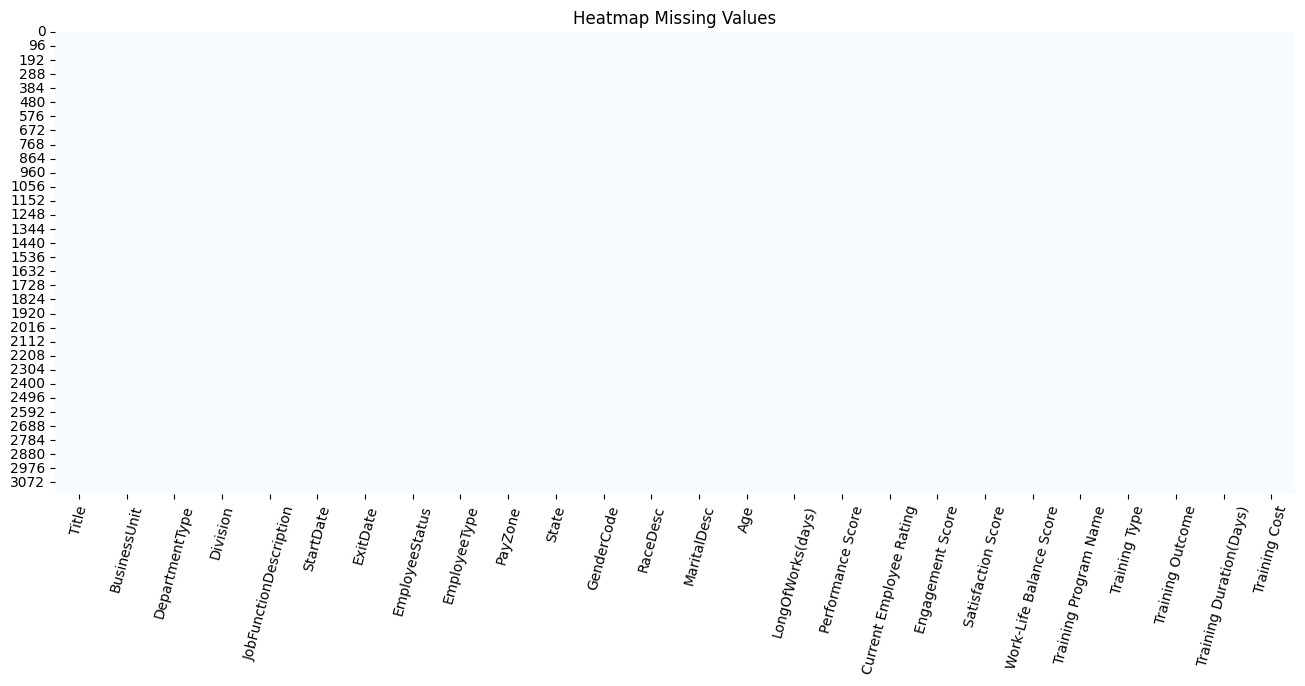

In [808]:
from IPython.display import display

display(df.isna().sum().to_frame().T.style.set_properties(**df_style).set_table_styles(table_style))
print("biar lebih jelas saya menggunakan heatmap")

plt.figure(figsize=(16, 6))
sns.heatmap(df.isna(), cbar=False, cmap='Blues')
plt.title("Heatmap Missing Values")
plt.xticks(rotation=75)
plt.show()

Sip tidak ada missing value!!!

#### Drop missing value<br>
Karena tidak ada data yang null, nan, nat atau missing value maka kita tidak perlu menanganinya

dibawah adalah cara-cara saya untuk mengisi missing value:

In [809]:
# drop jika total missing val < 12%
# df.dropna(inplace=True)


# Mean (rata-rata)
# df[col].fillna(df[col].mean(), inplace=True)
# Group-wise Imputation / Mean berdasarkan suatu group
# df[col1] = df.groupby(col2)[col1].transform(lambda x: x.fillna(x.mean()))

# Median (nilai tengah)
# df[col].fillna(df[col].median(), inplace=True)

# Modus (nilai yg sering muncul)
# df[col].fillna(df[col].mode()[0], inplace=True)

# isi dengan value 'unknown'
# df[col].fillna("unknown", inplace=True)

# Jika TIME SERIES
# Forward / Backward Fill
# Fordward Fill: isi dengan data yang sama dari 1 cel sebelumnya
# df[col].fillna(method='bfill', inplace=True)

# Backward Fill: isi dengan data yang sama dari 1 cel setelahnya
# df[col].fillna(method='ffill', inplace=True)

# Jika time series berurutan
# df[col].interpolate(method='linear', inplace=True)

# Menggunakan MODEL KNNImputer

#### Mengecek apakah ada yang duplikat? Dan hapus jika ada

In [810]:
print(f"Before: {df.duplicated().sum()} total | length datasets {df.shape}")

# Hapus
df.drop_duplicates(inplace=True)

# lihat kembali
print(f"After: {df.duplicated().sum()} total | length datasets {df.shape}")

Before: 150 total | length datasets (3150, 26)
After: 0 total | length datasets (3000, 26)


### Melihat deskripsi kolom Number & Kategorikal

#### Melihat deskripsi dari datasets number

In [811]:
df[num_cols].describe().T.style.set_properties(**df_style).set_table_styles(table_style)

,count,mean,std,min,25%,50%,75%,max
Current Employee Rating,3000.000000,2.969000,1.015078,1.000000,2.000000,3.000000,3.000000,5.000000
Engagement Score,3000.000000,2.939667,1.433426,1.000000,2.000000,3.000000,4.000000,5.000000
Satisfaction Score,3000.000000,3.022000,1.408845,1.000000,2.000000,3.000000,4.000000,5.000000
Work-Life Balance Score,3000.000000,2.989000,1.409329,1.000000,2.000000,3.000000,4.000000,5.000000
Training Duration(Days),3000.000000,2.975667,1.417890,1.000000,2.000000,3.000000,4.000000,5.000000
Training Cost,3000.000000,558.628697,263.217698,100.040000,327.587500,572.125000,786.987500,999.970000


__Cara membaca deskripsi number__:<br>
1. count adalah total sampel pada kolom tersebut
2. mean adalah nilai rata-ratanya
3. std adalah standard deviation digunakan untuk mengukur rentan nilai dari rata-rata
4. min nilai terkecil
5. 25% adalah quartil 1
6. 25% adalah quartil 2
7. 25% adalah quartil 3
8. max adalah nilai tertinggi

Dari data di atas cukup normal dan tidak ada outlier berdasarkan quartil 1 sampai max

#### Melihat deskripsi dari datasets categorical

In [812]:
df.describe(include="object").T.style.set_properties(**df_style).set_table_styles(table_style)

,count,unique,top,freq
Title,3000,31,Production Technician I,1321
BusinessUnit,3000,10,NEL,304
DepartmentType,3000,6,Production,2020
Division,3000,25,Field Operations,789
JobFunctionDescription,3000,83,Laborer,522
EmployeeStatus,3000,2,Non-Active,1533
EmployeeType,3000,3,Full-Time,1038
PayZone,3000,3,Zone A,1062
State,3000,28,MA,2651
GenderCode,3000,2,Female,1682


__Cara membaca deskripsi number__:<br>
1. count adalah total sampel pada kolom tersebut
2. unique adlaah jumlah berapa banyak data yang unik
3. top adalah nilai yang sering muncul / modus
4. freq adalah frekuensi berapa kali nilai top sering muncul

# Visualization for EDA

#### Setup color variance

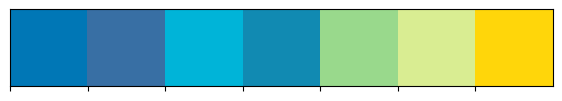

In [813]:
color_variance = ["#0077b6", "#386fa4", "#00b4d8", "#118ab2", "#99d98c", "#d9ed92", "#ffd60a"]

sns.palplot(sns.color_palette(color_variance))

Sepertinya bukan outlier, mungkin karena boxplot menggangap karena data jauh dari median atau Q3. Dan dalam khasus range masih dalam batas normal 1-5

### Memeriksa nilai outliers

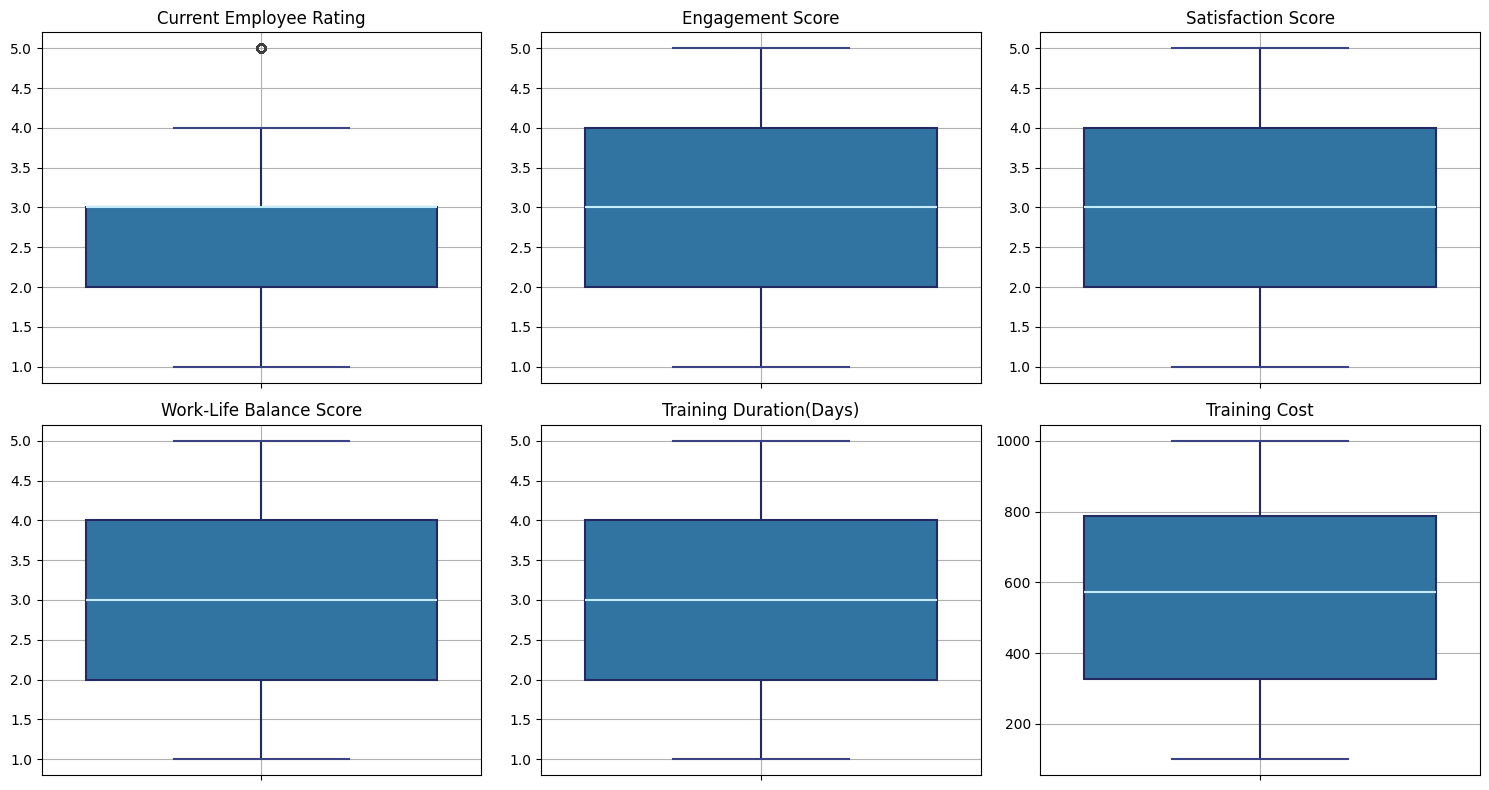

In [814]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
  data = df[col]

  axes[i].set_title(col.replace("_", " "))
  sns.boxplot(
    y=data,
    ax=axes[i],
    boxprops=dict(edgecolor=palatte[1], linewidth=1.5),
    whiskerprops=dict(color=palatte[1], linewidth=1.5),
    capprops=dict(color=palatte[2], linewidth=1.5),
    medianprops=dict(color=palatte[-1], linewidth=1.5)
  )
  axes[i].set_ylabel(None)
  axes[i].grid(True)

for j in range(len(num_cols), n_rows * n_cols):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Ada yang aneh pada Current Employee Rating, mari kita check

In [815]:
q1 = df['Current Employee Rating'].quantile(0.25)
q3 = df['Current Employee Rating'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outliers = df[df['Current Employee Rating'] > upper_bound]
print(df['Current Employee Rating'].value_counts())
outliers['Current Employee Rating']

Current Employee Rating
3    1530
2     510
4     419
1     271
5     270
Name: count, dtype: int64


,Current Employee Rating
9,5
10,5
22,5
37,5
58,5
...,...
2949,5
2955,5
2979,5
2980,5


### Analisis keseimbangan data / imbalance data<br
Bertujuan agar model nanti tidak bias ke value yang lebih banyak
<br>
Karena semua data kategori tidak lebih dari 5 maka saya bisa menggunakan pie chart untuk melihatnya

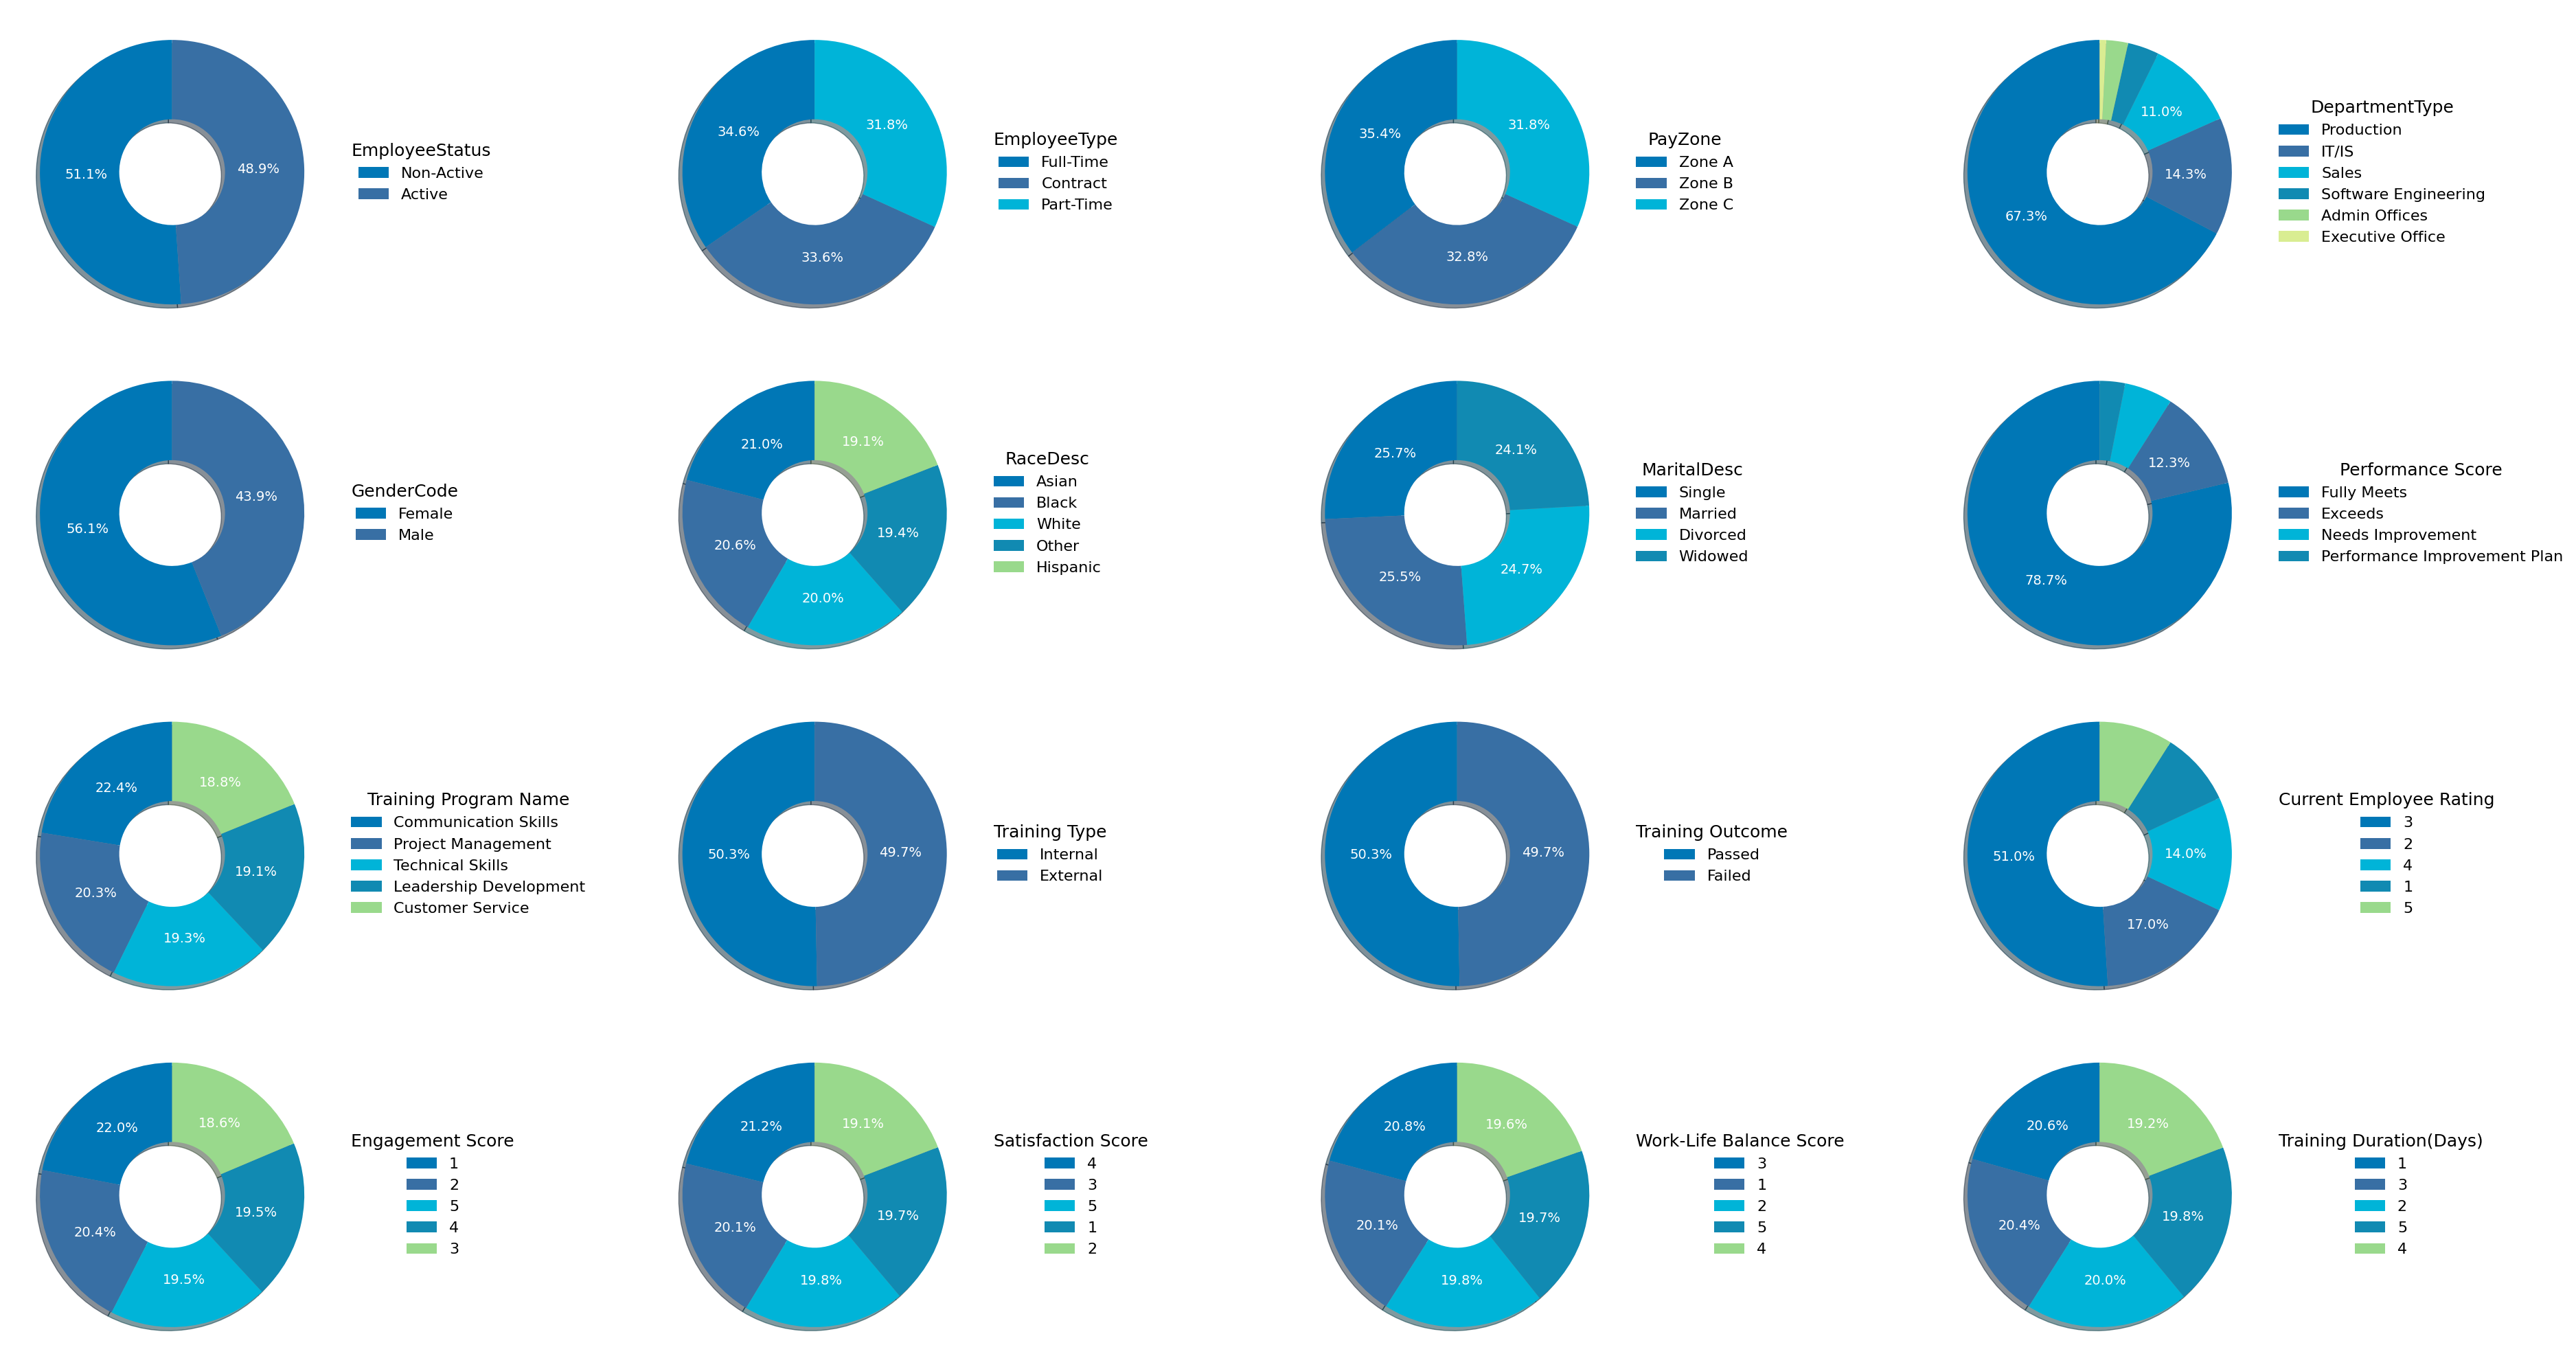

In [816]:
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*10, n_rows*5))
axes = axes.flatten()

plot_idx = 0

categoric_cols = [*cat_cols, *[col for col in num_cols if col != "Training Cost"]]
valid_cols = [col for col in categoric_cols if len(df[col].unique()) < 10]

for col in valid_cols:
  data = df[col].value_counts()

  wedges, texts, autotexts = axes[plot_idx].pie(
      x=data,
      autopct=lambda p: f"{p:.1f}%" if p >= 10 else "",
      startangle=90,
      colors=color_variance,
      pctdistance=0.65,
      wedgeprops=dict(width=0.6),
      shadow=True,
  )

  for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(14)

    axes[plot_idx].legend(
      wedges,
      [label for label in data.index],
      title=col.replace("_", " "),
      loc="center left",
      bbox_to_anchor=(1, 0.5),
      frameon=False,
      title_fontsize=18,
      fontsize=16
    )

  plot_idx += 1

# Hapus axes yang kosong
for j in range(plot_idx, n_rows * n_cols):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Pad data di atas ada beberapa kolom yang imbalance yakni:
1. DepartementType
2. Performance Score

Saya tidak akan melakukan sampling pada DepartementType terlebih dahulu karena
1. Data mempresentasikan keadaan perusahaan
2. Hubungan dengan variabel target yang belum di ketahui, jika hubungannya kuat maka saya akan melakukan sampling agar tidak bias.

Mengapa saya hanya melakukan sampling pada Performance Score saja? Data tersebut bagi saya tidak terlalu berarti pada target namun memiliki imbalance yang ekstrem bisa membuat model bisa pada data yang ekstreem.

#### Melihat data imbalance atau tidak pada data yang memiliki kateogori > 10

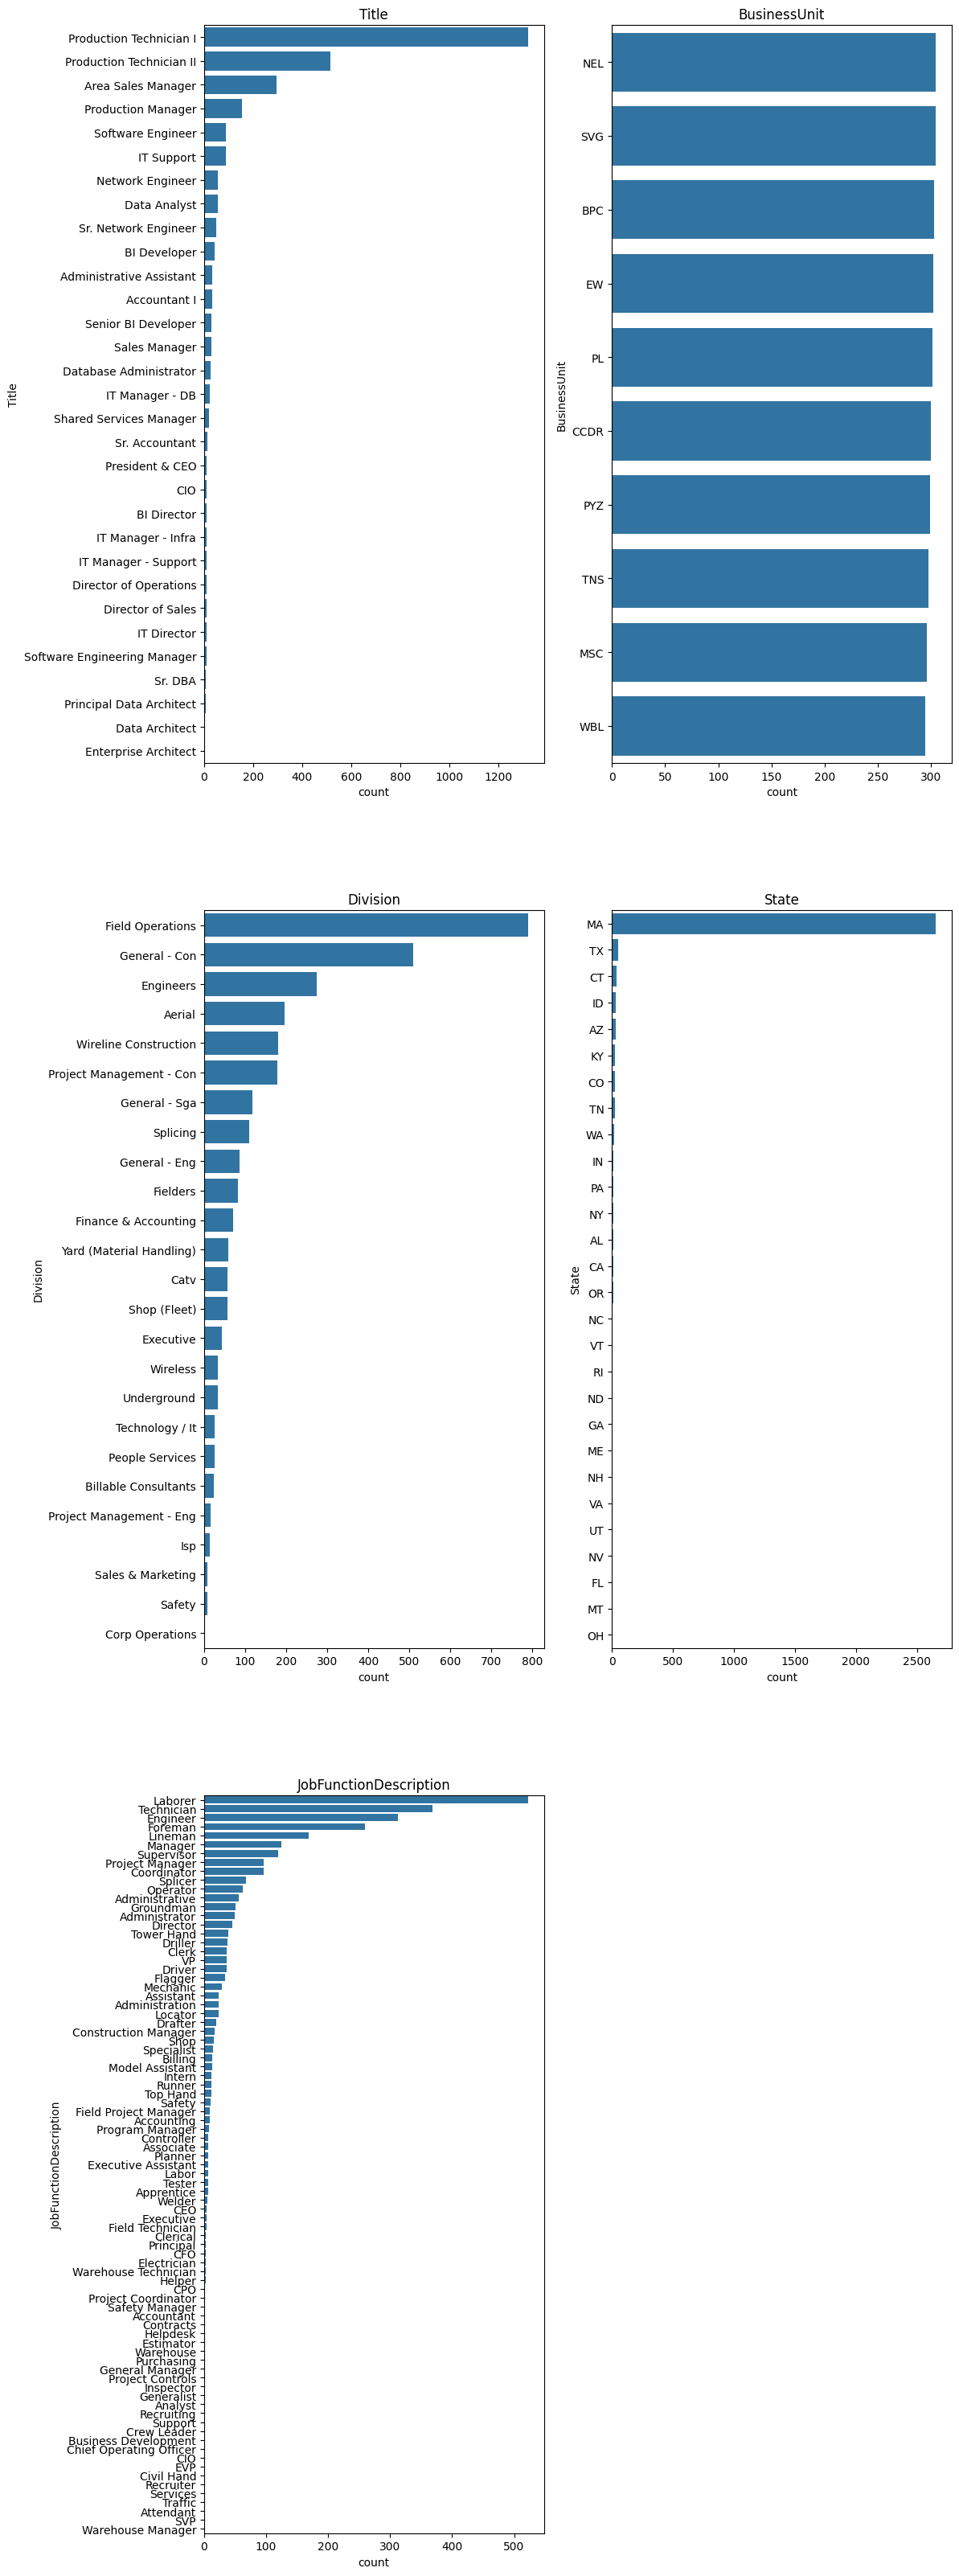

In [817]:
n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*14))
axes = axes.flatten()

plot_idx = 0

for col in categoric_cols:
  if len(df[col].unique()) < 10:
    continue

  axes[plot_idx].set_title(col)
  sns.countplot(
      y=col,
      data=df,
      ax=axes[plot_idx],
      order=df[col].value_counts().index,
  )

  plot_idx += 1

for j in range(plot_idx, n_rows * n_cols):
  fig.delaxes(axes[j])

plt.show()

Berdasarkan statistik countplot untuk melihat imbalance data ternyata hanya 1 kolom yang balance, untuk data lainnya yang imbalance saya tidak akan melakukan sampling karena data terlalu banyak dan ada beberpaa alasan lainnya:
1. Title / Jabatan dalam perusahaan karena tidak mungkin menambah sample data untuk jabatan yang tinggi.
2. Division tidak saya sampling karena mempresentasikan devisi-devisi yang ada di dalam perusahaan.
3. State saya putuskan drop karena ternyata mayoritas karyawan berasal dari kode negara MA
4. JobFunctionDescription saya putuskan drop juga karena ternyata 50% lebih job yang sangat sedikit terisi serta kolom JobFunctionDescription sebenarnya sudah di wakilkan oleh kolom Devision

In [818]:
df.drop(columns=["State", "JobFunctionDescription"], inplace=True)

# update columns
cat_cols.remove("State")
cat_cols.remove("JobFunctionDescription")

new_order_cols.remove("State")
new_order_cols.remove("JobFunctionDescription")

## Analisis Trend<br>
Bertujuan untuk bahan analisis HR atau perusahaan, misalnya prekrutan karyawan baru.

### Distribusi tahun masuk dan keluar karyawan

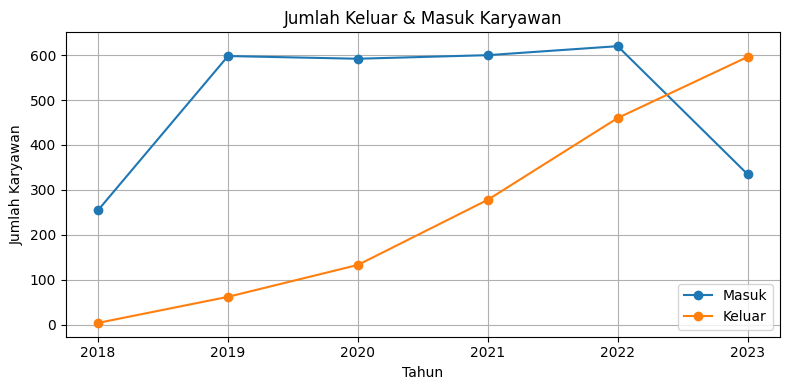

In [819]:
import datetime
current_year = datetime.datetime.now().year

analysis_trend = df.copy()
analysis_trend["StartDate"] = analysis_trend["StartDate"].dt.year
analysis_trend["ExitDate"] = analysis_trend["ExitDate"].dt.year

start_trend = analysis_trend.groupby('StartDate').size()
exit_trend = analysis_trend[analysis_trend["ExitDate"] < current_year].groupby('ExitDate').size()

plt.figure(figsize=(8, 4))
plt.title("Jumlah Keluar & Masuk Karyawan")
plt.plot(start_trend.index, start_trend.values, marker="o", label="Masuk")
plt.plot(exit_trend.index, exit_trend.values, marker="o", label="Keluar")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Karyawan")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [820]:
# Hapus kolom StartDate & ExitDate karena informasi sudah di pindah ke lama bekerja dalam hari
df.drop(columns=["StartDate", "ExitDate"], inplace=True)

# hapus pada order
new_order_cols.remove("StartDate")
new_order_cols.remove("ExitDate")

Tujuan menggunakan chart:
Dapat digunakan oleh HR / Perusahaan untuk menganalisa mengapa karyawan masuk dan keluar pada tahun tertentu.

Kesimpulannya pada chart:
- __Tren Masuk Karyawan:__<br>
Perusahaan mengalami peningkatan signifikan dalam perekrutan karyawan dari tahun 2018 hingga mencapai puncaknya pada tahun 2019-2022. Namun, pada tahun 2023 terjadi penurunan jumlah karyawan yang masuk, yang mengindikasikan adanya penyesuaian kebutuhan tenaga kerja atau efisiensi operasional di tahun tersebut.

- __Tren Keluar Karyawan:__<br>
Jumlah karyawan yang keluar menunjukkan tren yang terus meningkat dari tahun ke tahun. Puncaknya terjadi pada tahun 2023, di mana angka karyawan yang keluar hampir menyamai atau bahkan mendekati angka karyawan yang masuk di tahun-tahun sebelumnya. Hal ini dapat mencerminkan adanya dinamika internal seperti restrukturisasi, turnover yang tinggi, atau faktor eksternal lain yang memengaruhi tingkat retensi karyawan.

#### Melihat distribusi EmployeeStatus berdasarkan usia & gender<br>
Bertujuan untuk melihat di rentan usia berapa yang masuk dan keluar berdasarkan gender

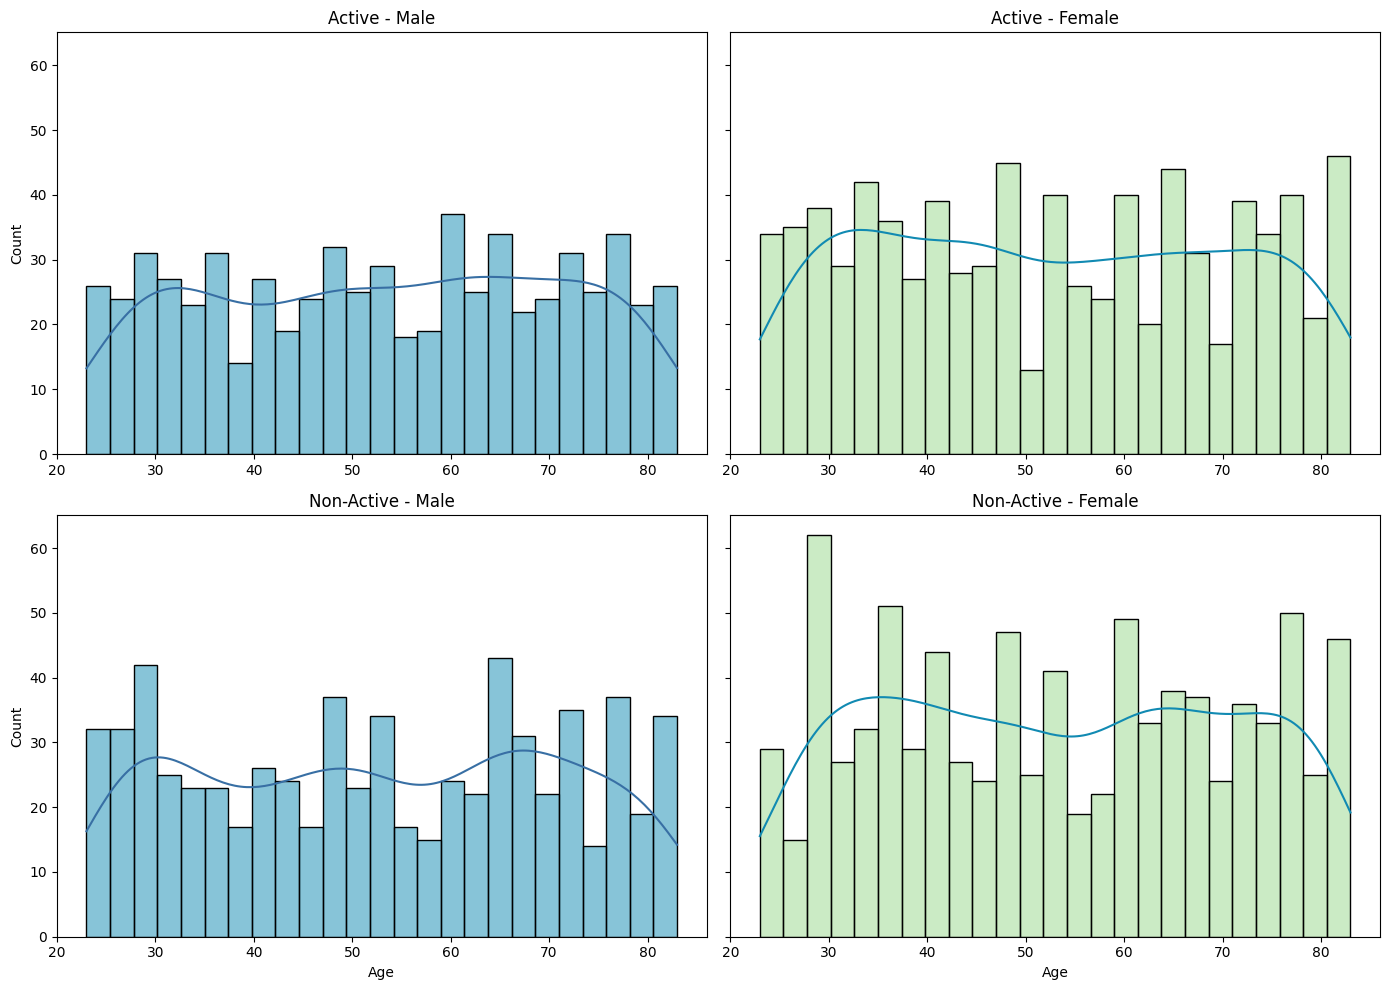

In [821]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

employee_status = ["Active", "Non-Active"]
genders = ["Male", "Female"]

for i, test in enumerate(employee_status):
    test_df = df[df["EmployeeStatus"] == test]
    for j, gender in enumerate(genders):
        ax = axes[i, j]
        color_fill = color_variance[3] if gender == "Male" else color_variance[4]
        color_line = color_variance[1] if gender == "Male" else color_variance[3]

        sns.histplot(
            test_df[test_df["GenderCode"] == gender]["Age"],
            color=color_fill,
            kde=True,
            bins=25,
            ax=ax
        )
        ax.lines[0].set_color(color_line)
        ax.set_title(f"{test} - {gender}")
        ax.tick_params(axis='x', which='both', labelbottom=True)

plt.tight_layout()
plt.show()


Tujuan menggunakan chart:
Mengetahui apakah faktor umur / gender mempengaruhi dalam perfroma bekerja? Dari distribusi di atas ternyata umur / gender tidak mempengaruhi performa dalam bekerja.

Kesimpulann pada chart:

1. __Distribusi Usia Karyawan Aktif:__
- __Pria Aktif:__<br>.
Distribusi usia pria yang aktif cukup merata di semua rentang usia, dengan kecenderungan lebih tinggi pada usia 30-an dan 60-an. Tidak ada konsentrasi yang terlalu dominan, namun terlihat adanya distribusi yang stabil antara usia 25 hingga 75 tahun.

- __Wanita Aktif:__<br>
Distribusi wanita aktif juga cukup tersebar, namun terdapat sedikit konsentrasi di usia 30-35 tahun dan usia 50-55 tahun. Setelah usia 70 tahun, jumlah wanita aktif tetap stabil namun sedikit menurun.

2. __Distribusi Usia Karyawan Non-Aktif:__
- __Pria Non-Aktif:__<br>
Karyawan pria non-aktif cenderung memiliki puncak distribusi pada usia sekitar 30 dan 65 tahun. Ini bisa menunjukkan adanya tren non-aktif pada pria di usia muda (sekitar 30) dan juga mendekati usia pensiun (60-70 tahun).

- __Wanita Non-Aktif:__<br>
Pada wanita non-aktif, terdapat puncak distribusi di usia 30-an dan 60-an. Terlihat bahwa usia non-aktif lebih banyak terjadi pada usia 30-an dan kemudian meningkat kembali pada usia mendekati pensiun (sekitar 60-70 tahun).

#### Melihat berapa banyak EmployeeStatus berdasarkan BusinessUnit dan DepartmentType

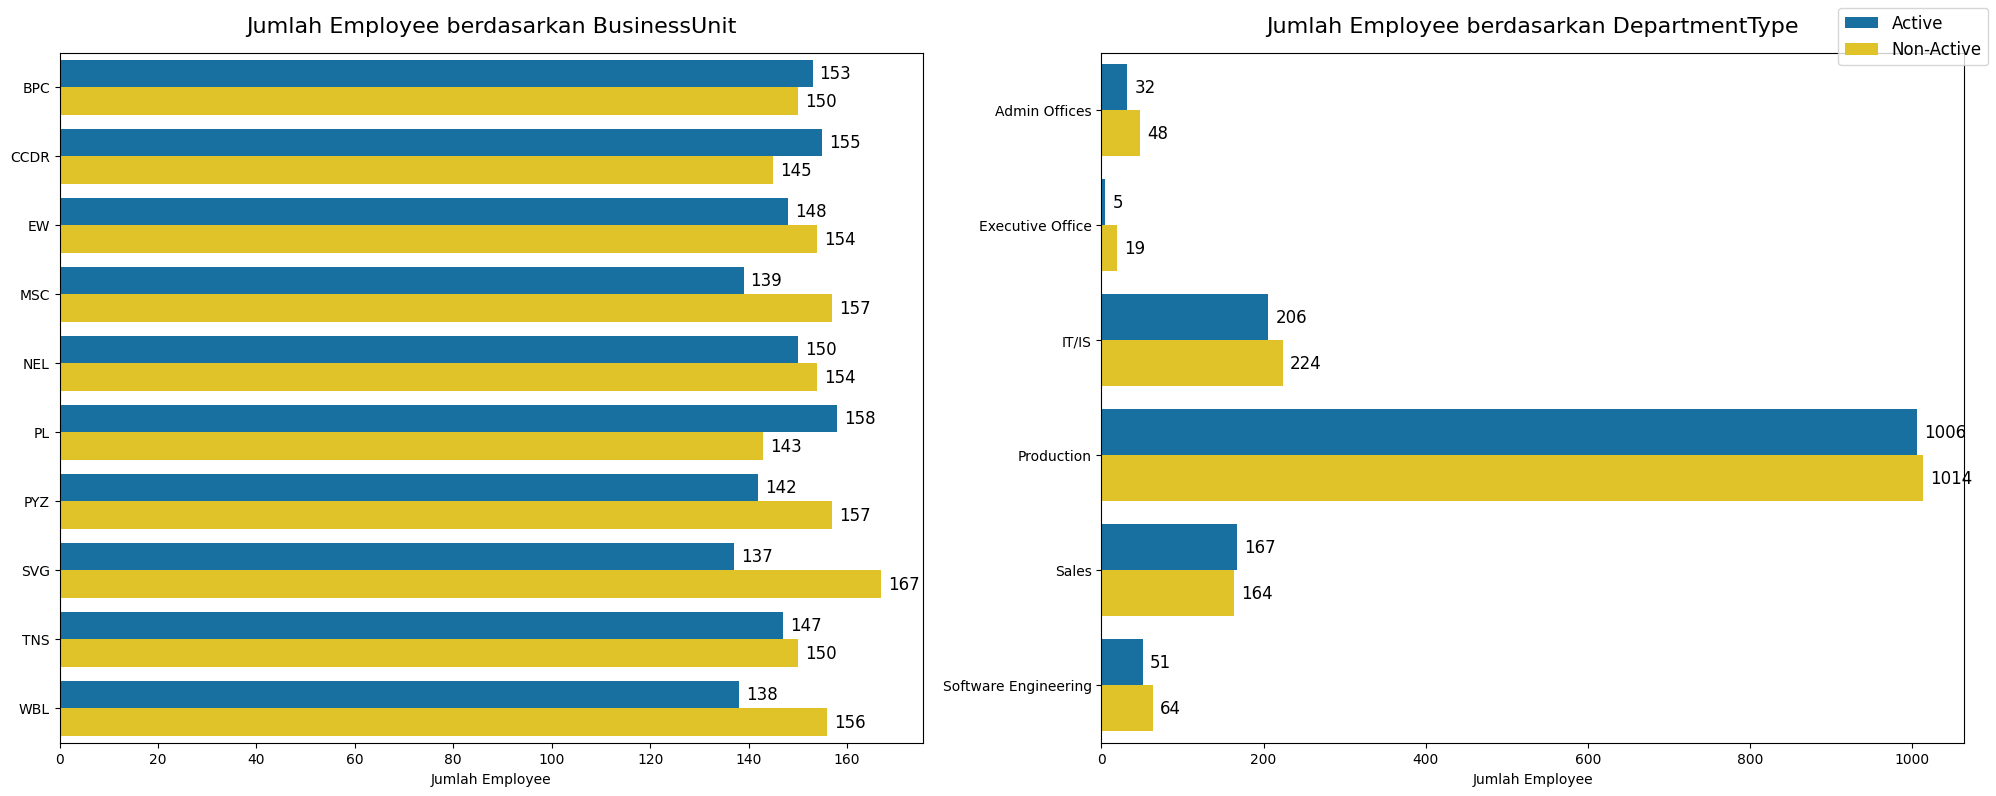

In [822]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, col in enumerate(["BusinessUnit", "DepartmentType"]):
    df_plot = df.groupby([col, "EmployeeStatus"]).size().reset_index(name="Jumlah")
    p = sns.barplot(
        data=df_plot,
        y=col,
        x="Jumlah",
        hue="EmployeeStatus",
        ax=axes[i],
        palette=[color_variance[0], color_variance[-1]]
    )
    axes[i].set_title(f"Jumlah Employee berdasarkan {col}", fontsize=16, pad=15)
    axes[i].set_xlabel("Jumlah Employee")
    axes[i].set_ylabel(None)

    for container in p.containers:
      p.bar_label(container, label_type="edge", padding=5, size=12, color="black")

for ax in axes:
    ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc="upper right",
    ncol=1,
    fontsize=12,

)

plt.tight_layout()
plt.show()

Tujuan menggunakna chart:
Bertujuan untuk mengethaui keseimbangan keluar masuk karyawan dalam BisnisUnit atau DepartmentType. Jika bentuk kedua bar tidak seimbang kemungkinan ada masalah pada unit bisnis atau tempat departmentnya. Untuk melihat lebih mudah dibawah saya membuat hasil selisih dan hasil dominannya.

Kesimpulan pada chart:
1. __Distribusi Berdasarkan Business Unit (kiri):__
  - Hampir semua Business Unit memiliki jumlah employee yang seimbang antara status Active dan Non-Active.

  - Unit seperti PL, SVG, dan WBL menunjukkan perbedaan yang sedikit lebih besar antara employee Active dan Non-Active.

  - Namun, secara umum, hampir semua Business Unit seperti BPC, CCDR, EW, MSC, NEL, PYZ, TNS menunjukkan selisih yang kecil antara status Active dan Non-Active.

2. __Distribusi Berdasarkan Department Type (kanan):__

  - Production merupakan department dengan jumlah karyawan terbanyak baik dalam status Active (1006) maupun Non-Active (1014).

  - IT/IS dan Sales juga menempati posisi teratas berikutnya, namun masih jauh di bawah jumlah yang ada di Production.

  - Department seperti Executive Office dan Admin Offices memiliki jumlah karyawan yang jauh lebih sedikit dibandingkan department lainnya.

  - Di Software Engineering, jumlah Non-Active (64) sedikit lebih banyak dibandingkan Active (51), menunjukkan potensi tren yang menarik untuk ditelusuri lebih lanjut.

Catatan tambahan, data di atas masih belum bercampur aduk, kita masih kesulihan melihat selisih dan hasil selisih dominan yang mana.

#### Menghitung selisah dan dominan Active atau Non-Active di BusinessUnit dan DepartmentType

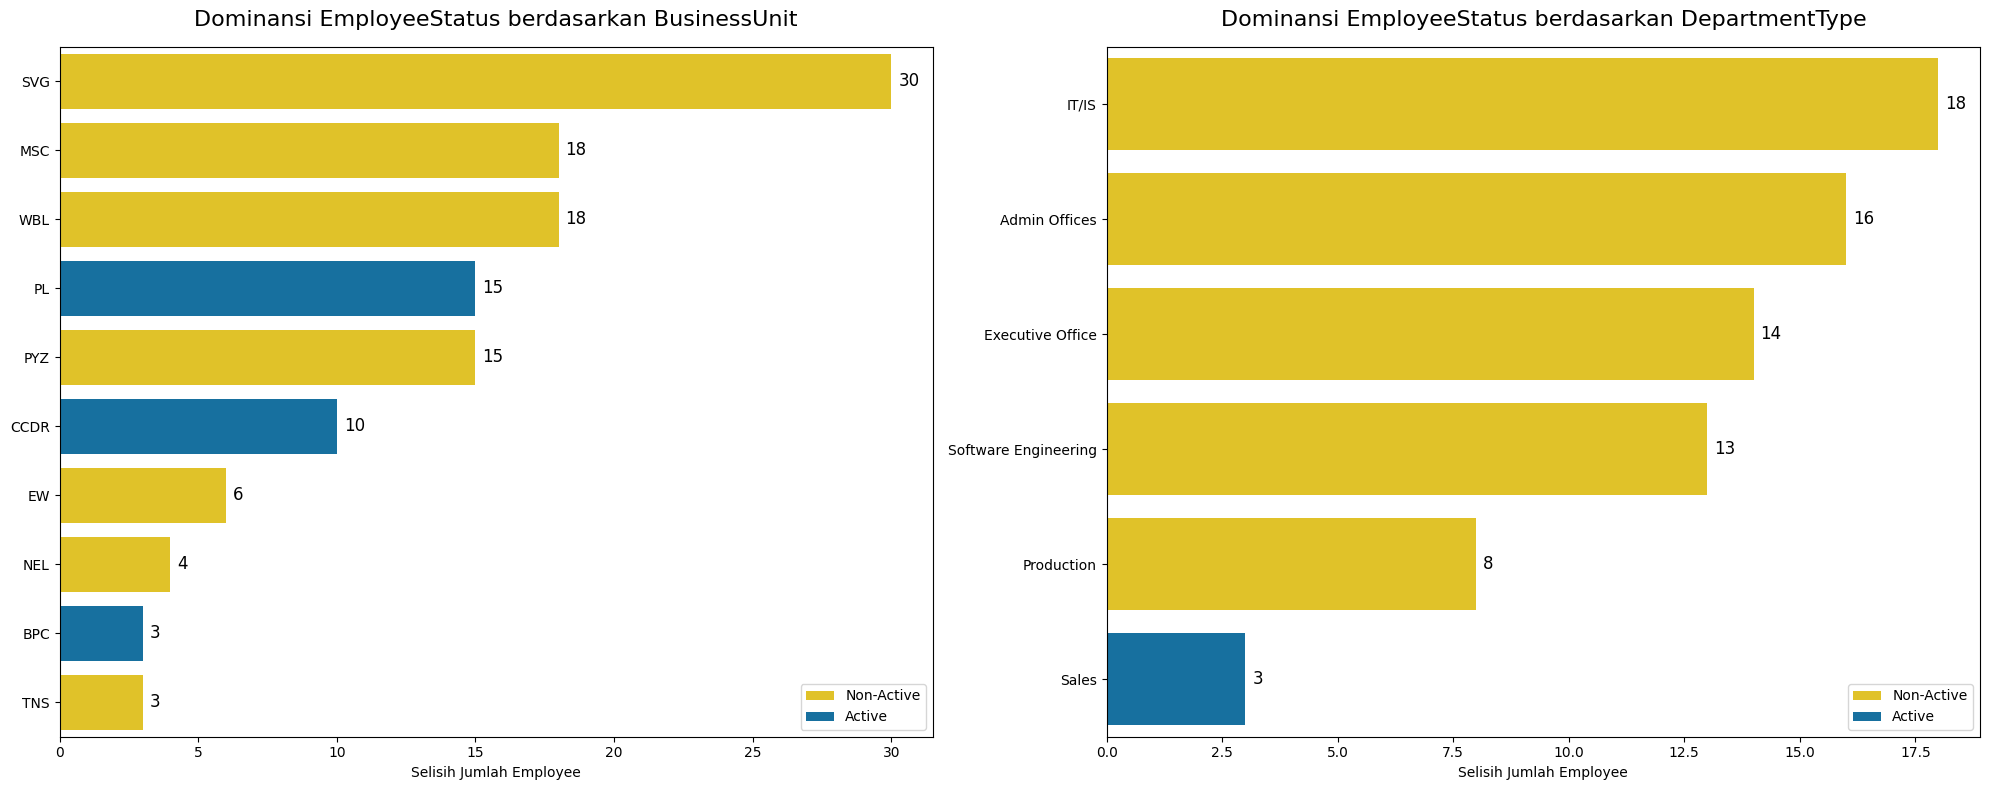

In [823]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for i, col in enumerate(["BusinessUnit", "DepartmentType"]):
    dominance = df.groupby([col, "EmployeeStatus"]).size().unstack(fill_value=0)
    dominance["Dominance"] = dominance.apply(lambda row: "Active" if row.get("Active", 0) > row.get("Non-Active", 0) else "Non-Active", axis=1)
    dominance["Diff"] = abs(dominance.get("Active", 0) - dominance.get("Non-Active", 0))
    dominance = dominance.reset_index()

    p = sns.barplot(
        data=dominance.sort_values("Diff", ascending=False),
        y=col,
        x="Diff",
        hue="Dominance",
        ax=axes[i],
        palette={"Active": color_variance[0], "Non-Active": color_variance[-1]}
    )
    axes[i].set_title(f"Dominansi EmployeeStatus berdasarkan {col}", fontsize=16, pad=15)
    axes[i].set_xlabel("Selisih Jumlah Employee")
    axes[i].set_ylabel(None)
    axes[i].legend(loc="lower right")

    for container in p.containers:
      p.bar_label(container, label_type="edge", padding=5, size=12, color="black")

plt.tight_layout()
plt.show()

Tujuan:
Mengetahui selisih dan dominan masuk atau keluar karyawan dalam BusinessUnit dan DepartmentType agar HR / perusahaan dalam melakukan tindakan lanjut jika selisih non-active lebih banyak pada salah satu kolom BusinessUnit atau DepartmentType.

Kesimpulan pada chart:
1. Berdasarkan Business Unit (kiri):
SVG adalah unit dengan dominasi Non-Active paling tinggi, yaitu selisih 30 orang.

  - MSC dan WBL juga menunjukkan dominasi Non-Active yang signifikan, masing-masing dengan selisih 18 orang.

  - PL dan CCDR justru menunjukkan dominasi Active, dengan PL (selisih 15 ke arah Active) dan CCDR (selisih 10 ke arah Active).

  - Beberapa unit seperti TNS, BPC, dan NEL memiliki gap yang relatif kecil, menunjukkan keseimbangan antara Active dan Non-Active.

2. Berdasarkan Department Type (kanan):
  - Hampir semua department menunjukkan dominasi Non-Active, kecuali Sales, yang memiliki sedikit keunggulan di status Active dengan selisih 3 orang.

  - IT/IS dan Admin Offices memiliki selisih tertinggi menuju Non-Active masing-masing 18 dan 16 orang.

  - Production yang sebelumnya memiliki jumlah total tertinggi, ternyata memiliki selisih Non-Active sebesar 8, yang masih tergolong moderat jika dibandingkan dengan department lain.

  - Software Engineering dan Executive Office juga cukup dominan Non-Active dengan selisih masing-masing 13 dan 14.


__Insight tambahan:__
- Dari perspektif Business Unit, distribusi lebih bervariasi (ada yang dominan Active dan Non-Active).

- Dari perspektif Department Type, dominasi Non-Active lebih merata hampir di semua department.


#### Analisis apakah ada kesenjangan sosial?

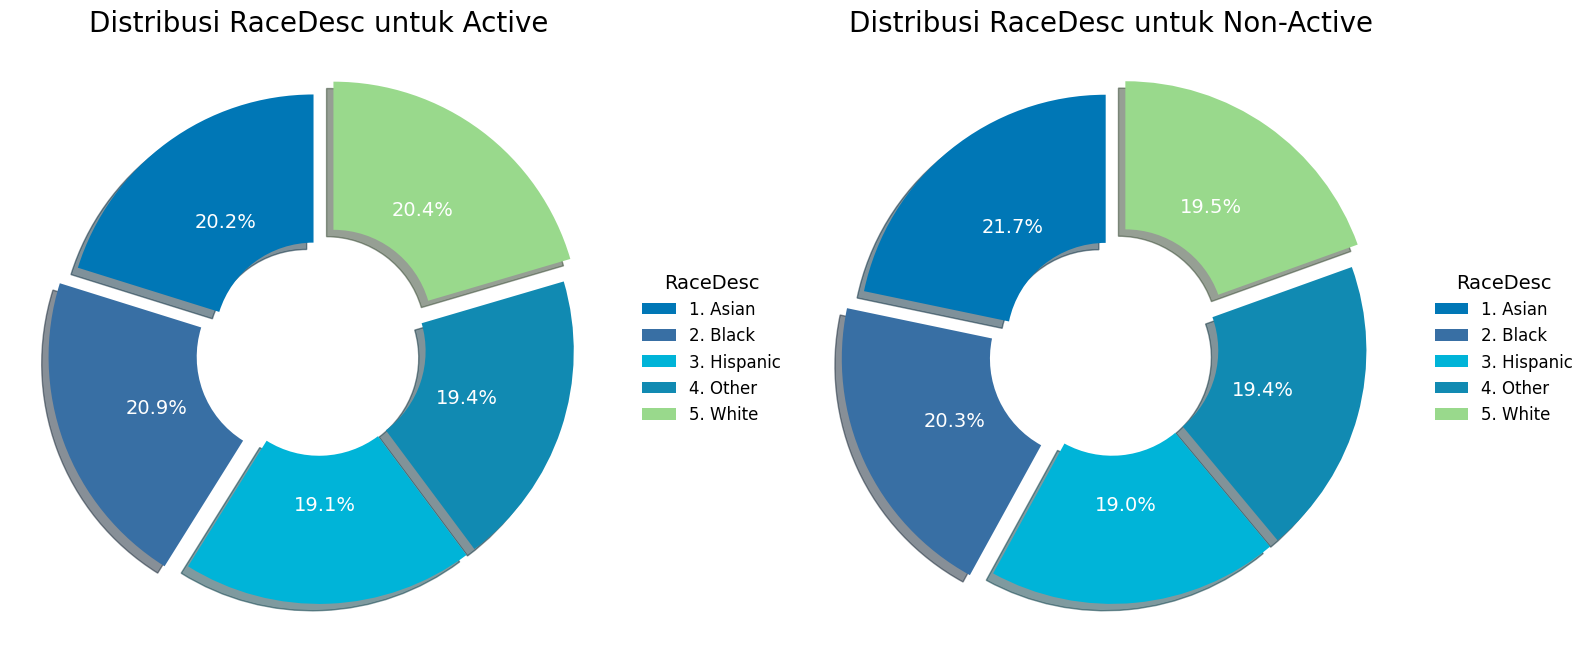

In [824]:
grouped = df.groupby(['EmployeeStatus', "RaceDesc"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(1, 2, figsize=(16, 10))

for i, status in enumerate(grouped.index):
    data = grouped.loc[status]
    wadges, texts, autotexts = ax[i].pie(
        data,
        autopct='%1.1f%%',
        startangle=90,
        shadow=True,
        explode=(0.035,0.1,0.035,0.035,0.1),
        wedgeprops=dict(width=0.6),
        colors=color_variance,
    )
    ax[i].set_title(f'Distribusi RaceDesc untuk {status}', size=20)

    for autotext in autotexts:
      autotext.set_color("white")
      autotext.set_fontsize(14)

      ax[i].legend(
        wedges,
        [f"{i+1}. {label}" for i, label in enumerate(data.index)],
        title="RaceDesc",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False,
        title_fontsize=14,
        fontsize=12
      )

plt.tight_layout()
plt.show()

Tujuan:<br>
Menganalisis apakah ada kesenjangan sosial berdasarkan ras atau warna kulitnya di dalam kantor.

Kesimpulan:<br>
Ternyata tidak ada kesenjangan sosial di kantor di karenakan berdasarkan plot di atas sangat seimbang.

#### Analisis lama bekerja karyawan apakah mempengaruhi karyawan keluar

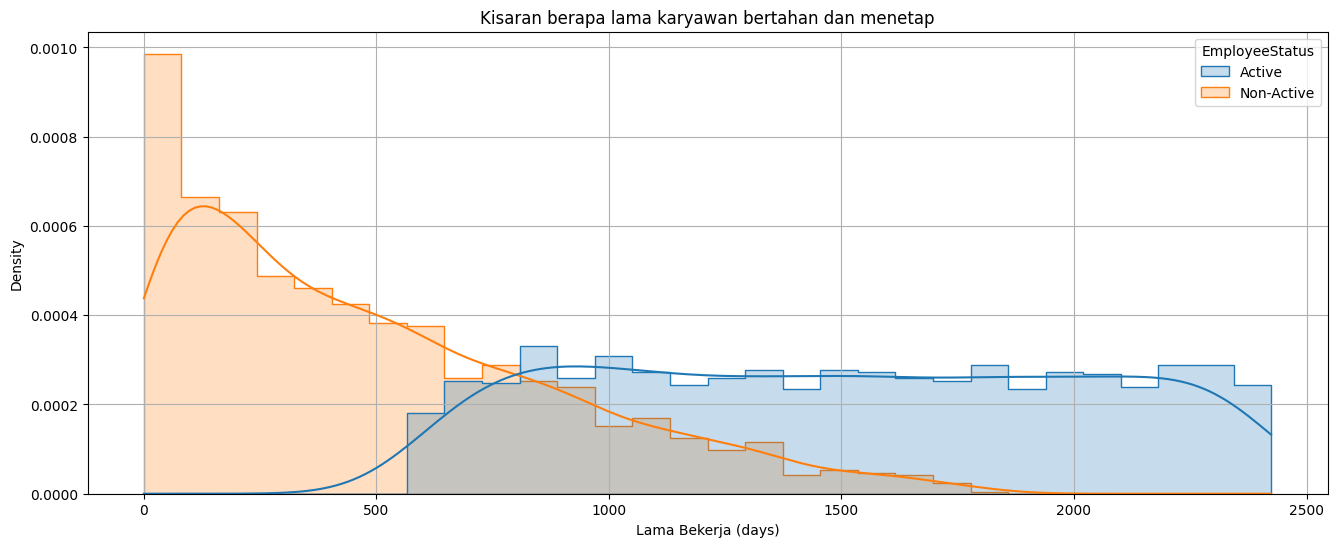

In [825]:
plt.figure(figsize=(16,6))
sns.histplot(data=df, x="LongOfWorks(days)", hue="EmployeeStatus", bins=30, kde=True, element="step", stat="density")
plt.title("Kisaran berapa lama karyawan bertahan dan menetap")
plt.xlabel("Lama Bekerja (days)")
plt.ylabel("Density")
plt.grid(True)
plt.show()

Tujuan:<br>
Melihat apakah di kisaran berapa karyawan keluar berdasarkan berapa lama karyawan bekerja dalam bentuk hari.

Kesimpulan:<br>
- Plot menunjukkan bahwa karyawan di rentan 2 tahun san seteruskan akan menetap / berthaan di kantor
- Sedangkan karyawan yang bekerja di bawah 2-4 tahun memiliki kemungkinan besar karyawan akan keluar.

Berdasarkan plot di atas ada suatu masalah mengapa karyawan hanya bertahan di kisaran 2 tahun

#### Analisis apakah rating kesejahteraan hidup pribadi dan kantor

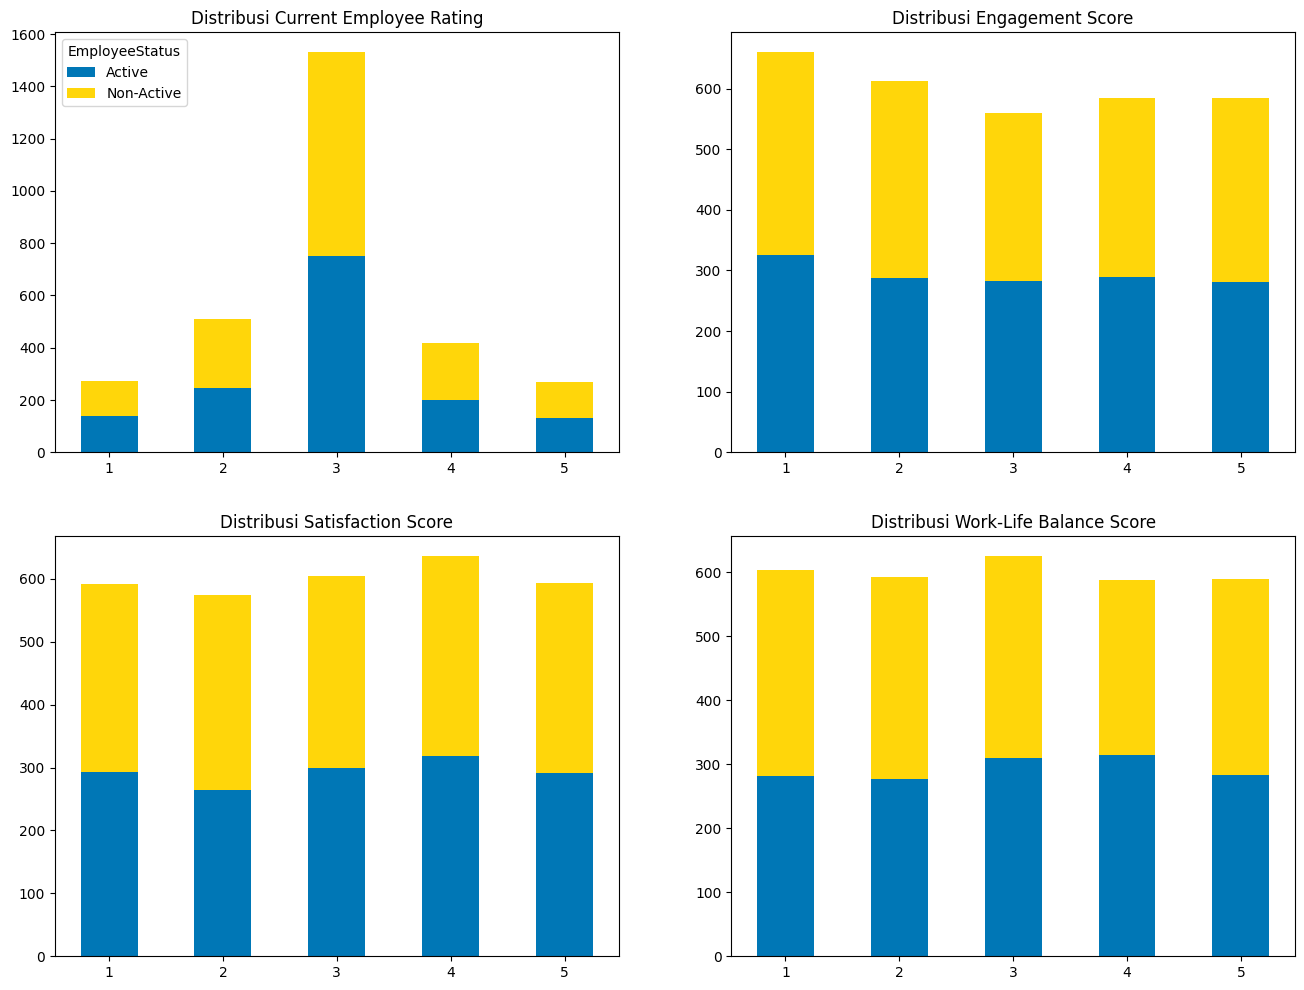

In [826]:
rating_cols = ["Current Employee Rating", "Engagement Score",	"Satisfaction Score", "Work-Life Balance Score"]

ratings = [1, 2, 3, 4, 5]
width = 0.5

n_cols = 2
n_rows = math.ceil(len(rating_cols) / n_cols)

fig, ax = plt.subplots(n_cols, n_rows, figsize=(n_cols*8, n_rows*6))
ax = ax.flatten()
bar_colors = {"Active": color_variance[0], "Non-Active": color_variance[-1]}

for i, col in enumerate(rating_cols):
  bottom = np.zeros(len(ratings))
  rating_counts = df.groupby(['EmployeeStatus', col]).size().unstack(fill_value=0)

  weight_counts = {
      "Active": rating_counts.loc["Active", ratings].values,
      "Non-Active": rating_counts.loc["Non-Active", ratings].values,
  }

  for label, count in weight_counts.items():
      p = ax[i].bar(
          ratings,
          count,
          width,
          label=label,
          bottom=bottom,
          color=bar_colors[label])
      bottom += count

  ax[i].set_title(f"Distribusi {col}")
  ax[i].set_xticks(ratings)
  if i == 0:
    ax[i].legend(title="EmployeeStatus", loc="upper left")

plt.show()

Tujuan:<br>
Mengetahui apakah kesejahteraan hidup pribadi dan kantor mempengaruhi performa pekerjaan sampai karyawan tetap aktif atau keluar? Ternyata dari chart di atas tidak memperngaruhi.

Kesimpulan:
- Data selisih sangat seimbang dan tidak memiliki dominan.
- Persebaran pada Current Employee Rating pada rating 3 paling banyak, karena saat melihat keseimbangan data menggunakan pie chart Current Employee Rating memang sedikit imbalance, serta rating 3 ini juga paling banyak dari yang lain sampai banyaknya 1600.
- Untuk persebaran data lainnya sangat imbang dan tidak di permasalahnkan.

#### Melihat distribusi harga training

<ipython-input-827-7dead988c401>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


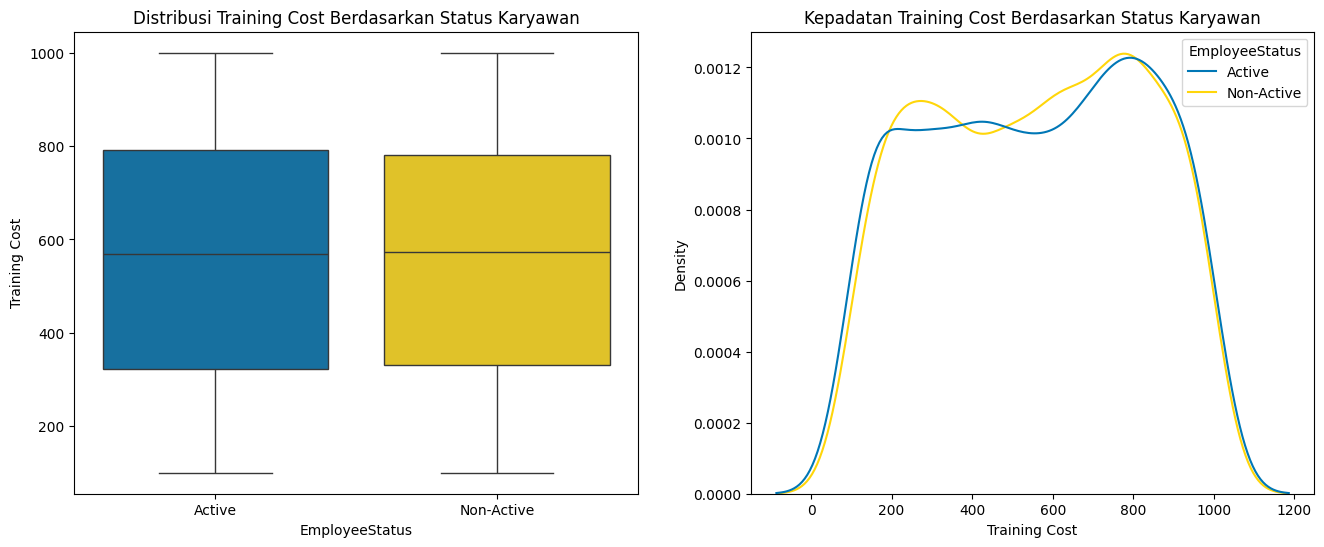

In [827]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot untuk membandingkan distribusi biaya training
sns.boxplot(
    data=df,
    x='EmployeeStatus',
    y='Training Cost',
    ax=ax[0],
    palette=[color_variance[0], color_variance[-1]]
)
ax[0].set_title("Distribusi Training Cost Berdasarkan Status Karyawan")

# KDE Plot untuk melihat distribusi biaya training
sns.kdeplot(
    data=df,
    x='Training Cost',
    hue='EmployeeStatus',
    common_norm=False,
    ax=ax[1],
    palette=[color_variance[0], color_variance[-1]]
)
ax[1].set_title("Kepadatan Training Cost Berdasarkan Status Karyawan")

plt.show()


Tujuan:<br>
Mengetahui apakah biaya training yang lebih banyak bisa mempengaruhi karyawan kompoten tetap bertahan di kantor apa tidak.

Kesimpulan:<br>


## Pre-processing

### Sampling

In [828]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from imblearn.over_sampling import SMOTENC

X_samp = df.drop(columns=['Performance Score', 'Current Employee Rating'])
y_samp = df[['Performance Score', 'Current Employee Rating']]

cat_features = [col for col in cat_cols if col != "Performance Score"]
cat_idx = [X_samp.columns.get_loc(col) for col in cat_features]

# Encode
oe = OrdinalEncoder()
X_samp[cat_features] = oe.fit_transform(X_samp[cat_features])
cat_idx = [X_samp.columns.get_loc(col) for col in cat_features]

le = LabelEncoder()
y_target_enc = le.fit_transform(y_samp['Performance Score'])

# Oversampling
smote_nc = SMOTENC(categorical_features=cat_idx, random_state=42)
X_smo, y_smo = smote_nc.fit_resample(X_samp, y_target_enc)

# Decode
X_smo = pd.DataFrame(X_smo, columns=X_samp.columns)
X_smo[cat_features] = oe.inverse_transform(X_smo[cat_features])
y_smo = le.inverse_transform(y_smo)

# to dataframe
sampler_df = pd.concat([
    X_smo.reset_index(drop=True),
    pd.DataFrame(y_smo, columns=['Performance Score']),
    pd.Series(y_samp['Current Employee Rating'].sample(len(X_smo), replace=True).values,
              name='Current Employee Rating')
], axis=1)

# Susun ulang kolom
sampler_df = sampler_df[new_order_cols]

#### Melihat kembali hasil sampling

Ukuran datasets sampler: (9444, 22)


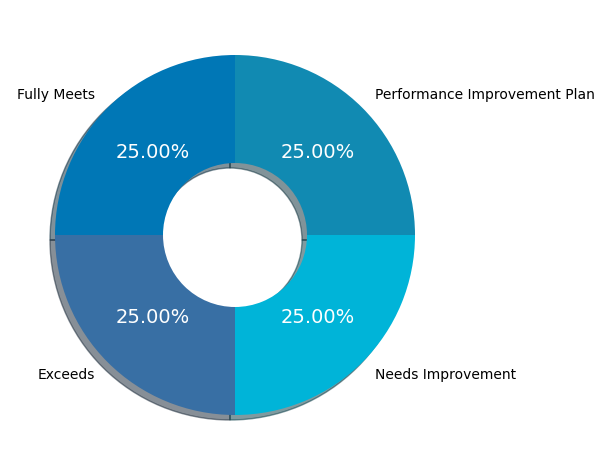

In [829]:
print(f"Ukuran datasets sampler: {sampler_df.shape}")

data = sampler_df["Performance Score"].value_counts()

wedges, texts, autotexts = plt.pie(
    x=data,
    labels=data.keys(),
    autopct="%.2f%%",
    startangle=90,
    colors=color_variance,
    pctdistance=0.65,
    wedgeprops=dict(width=0.6),
    shadow=True,
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(14)

plt.tight_layout()
plt.show()

Hasilnya sudah sangat balance, namun mari kita lihat apakah mempengaruhi kolom yang lainnya?

#### Memastikan hasilnya tidak terlalu merubah keseimbangan data sebelumnya

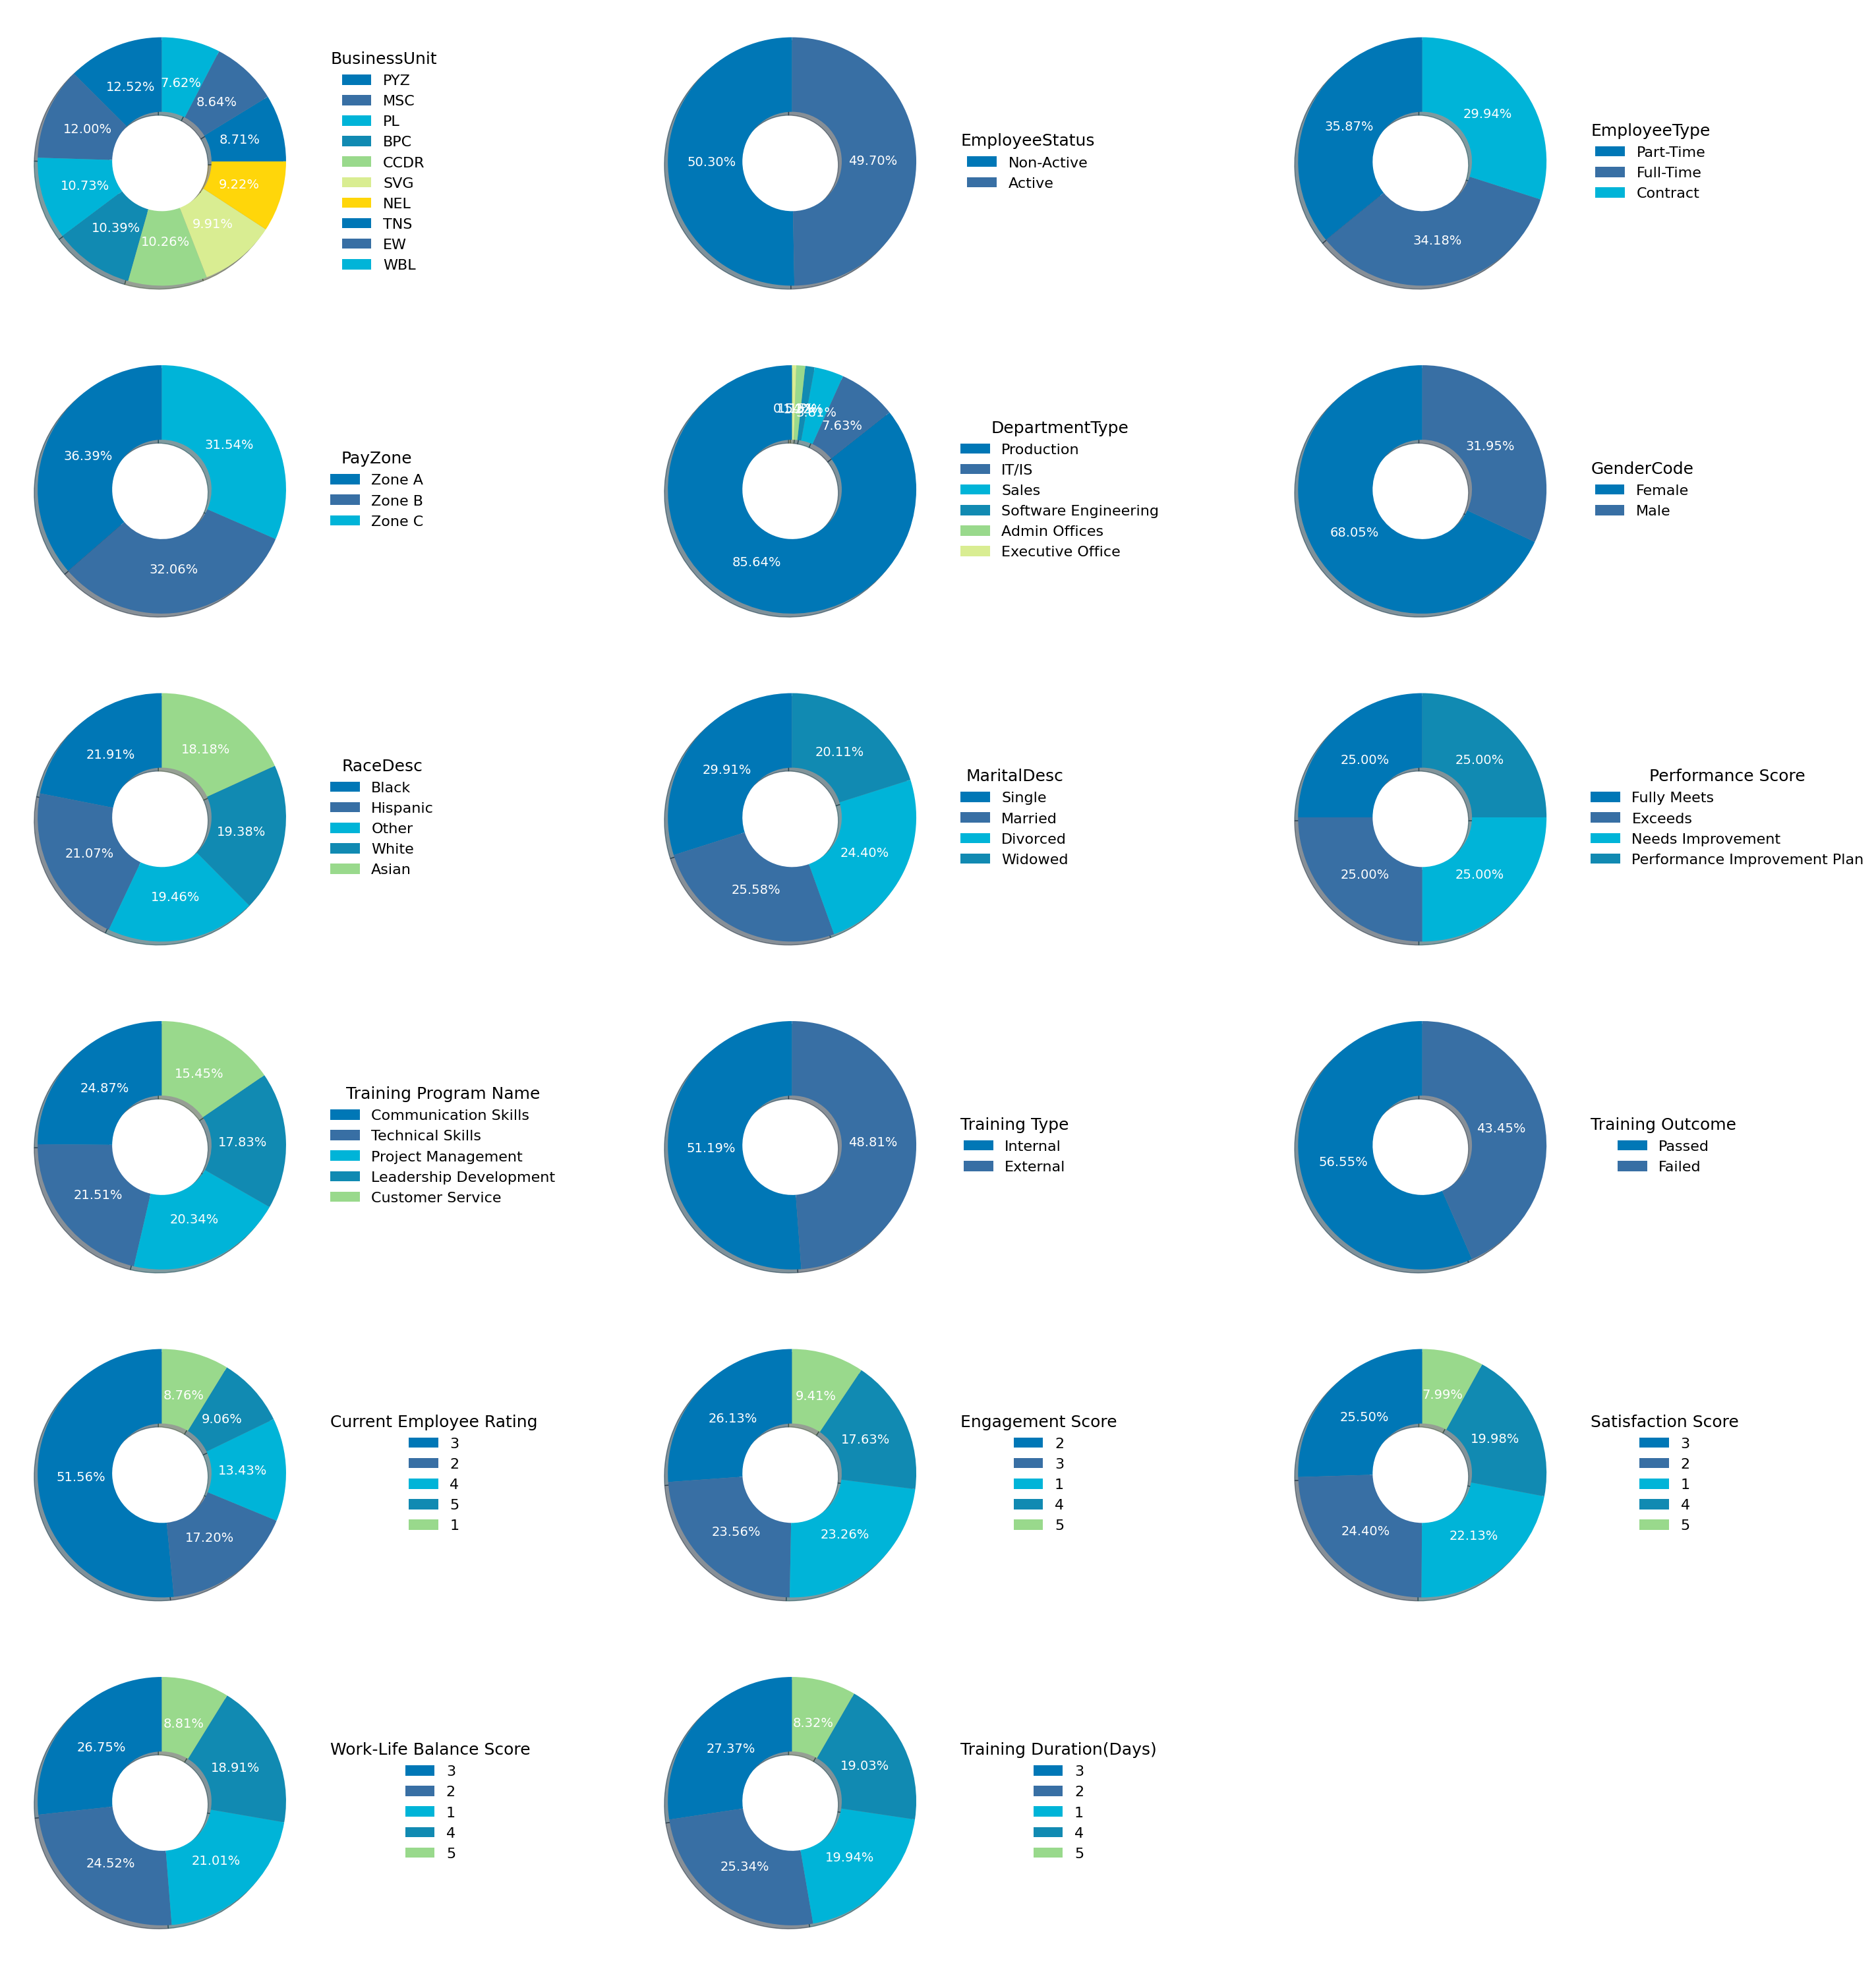

In [830]:
categoric_cols = [*cat_cols, *[col for col in num_cols if col != "Training Cost"]]
valid_cols = [col for col in categoric_cols if len(sampler_df[col].unique()) <= 10]

n_cols = 3
n_rows = math.ceil(len(valid_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*10, n_rows*5))
axes = axes.flatten()

for i, col in enumerate(valid_cols):
  data = sampler_df[col].value_counts()

  wedges, texts, autotexts = axes[i].pie(
      x=data,
      autopct="%.2f%%",
      startangle=90,
      colors=color_variance,
      pctdistance=0.65,
      wedgeprops=dict(width=0.6),
      shadow=True,
  )

  for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(14)

    axes[i].legend(
      wedges,
      [label for label in data.index],
      title=col.replace("_", " "),
      loc="center left",
      bbox_to_anchor=(1, 0.5),
      frameon=False,
      title_fontsize=18,
      fontsize=16
    )


# Hapus axes yang kosong
for j in range(len(valid_cols), n_rows * n_cols):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Hasil sampler:<br>
Menunjukkan bahwa setelah sampler ada beberapa kolom yang menjadi moderat imbalance dan ekstrem imbalance, dengan kesimpulan saya, saya lebih memilih datasets sebelum di sampler di karenakan lebih baik mengorbankan 1 kolom biar daripada banyak ko

## Feature Selection

### Melihat Korelasi Kategorical / Campuran

#### Melihat seberapa kuat hubungan antaran variabel data kategorikal mengguanakan __Chi-Squared Test__

In [831]:
from scipy.stats import chi2_contingency

target = 'EmployeeStatus'
features = [col for col in df.columns if col != target]

results = []

for col in features:
    table = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({
        'Feature': col,
        'Chi2': chi2,
        'p-value': p,
        'Degrees of Freedom(dof)': dof
    })

# Convert ke dataframe hasil
chi_squared_df = pd.DataFrame(results)
chi_squared_df.sort_values('p-value').style.set_properties(**df_style).set_table_styles(table_style)

,Feature,Chi2,p-value,Degrees of Freedom(dof)
10,LongOfWorks(days),2436.327182,0.000000,1663
18,Training Outcome,7.147646,0.007506,1
2,DepartmentType,12.202500,0.032116,5
9,Age,75.497049,0.085629,60
15,Work-Life Balance Score,7.781968,0.099899,4
16,Training Program Name,4.024088,0.402756,4
5,PayZone,1.504110,0.471397,2
20,Training Cost,2955.978694,0.538087,2964
3,Division,20.931800,0.642745,24
14,Satisfaction Score,2.291058,0.682398,4


Dengan visualisasi

<ipython-input-832-6cfaf9878ae7>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  p = sns.barplot(


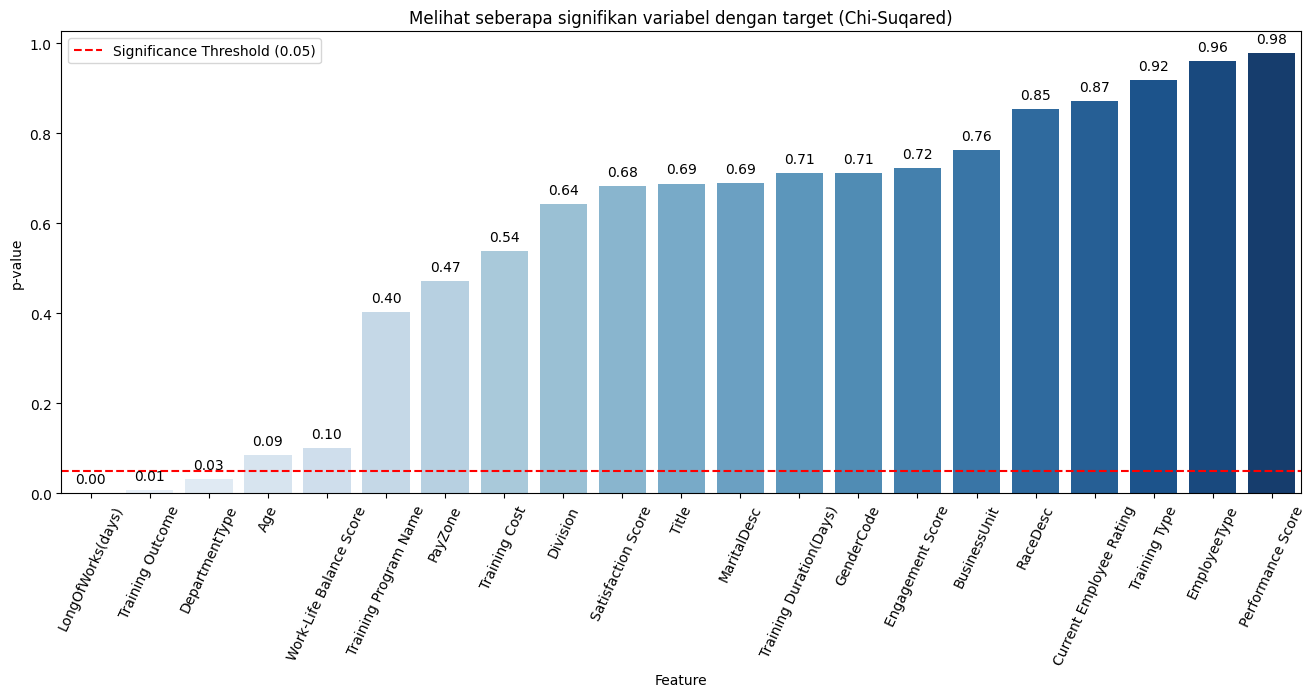

In [832]:
plt.figure(figsize=(16, 6))
p = sns.barplot(
    data=chi_squared_df.sort_values('p-value'),
    x="Feature",
    y="p-value",
    palette="Blues"
)

for container in p.containers:
  labels = [f"{val:.2f}" for val in container.datavalues]
  p.bar_label(container, labels=labels, label_type="edge", color="black", padding=5)

plt.title("Melihat seberapa signifikan variabel dengan target (Chi-Suqared)")
plt.axhline(0.05, color="red", linestyle="--", label="Significance Threshold (0.05)")
plt.xticks(rotation=65)
plt.legend()
plt.show()

#### Cara membaca Chi-Squared Test<br>
1. Feature adalah nama-nama fitur dari datasets
2. Chi2 adalah nilai statistik Chi-Square dari fitur seberapa berpengaruh terhadap nilai target
3. p-value adalah nilai yang digunakan untuk menentukan apakah ada hubungan yang spesifik antar fitur dan target. <br>Nilai < 0.05 adalah fitur yang signifikan, sebaliknya > 0.05 adalah fitur yang kurang signifikan

#### Melihat seberapa kuat hubungan antaran variabel data kategorikal mengguanakan __Cramér's V__<br>
Mengapa menggunakan Cramér's V? Karena variabel yang signifikan pada target belum terntu kuat hubungannya terhadap target. Untuk memastikan apakah hubunganya kuat saya menggunakan Cramér's V.

Rumus Cramér's V:
$$V = \sqrt{\frac{X^2}{n \cdot (k-1)}}$$

$X^2$ = Nilai Chi-Square<br>
$n$ = jumlah total observasi<br>
$k$ = jumlah kategori minimal pada X dan Y

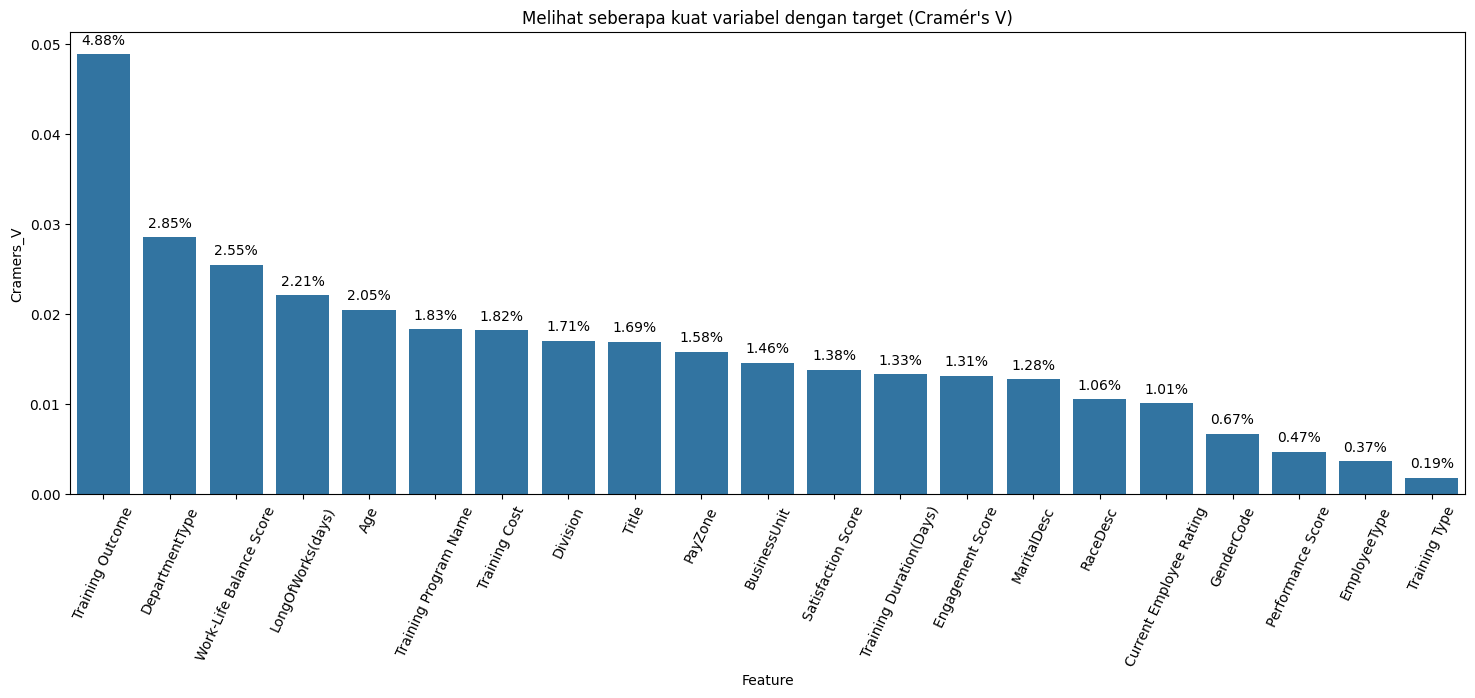

In [833]:
import numpy as np

n = df.shape[0]

def cramers_v(chi2, n, dof):
    k = dof + 1  # dof = k - 1 => k = dof + 1
    return np.sqrt(chi2 / (n * (k - 1)))

# Tambahkan kolom baru untuk hasil Cramér's V
chi_squared_df['Cramers_V'] = chi_squared_df.apply(lambda row: cramers_v(row['Chi2'], n, row['Degrees of Freedom(dof)']), axis=1)

cramersv_df = chi_squared_df[['Feature', 'Cramers_V']].sort_values('Cramers_V', ascending=False)

plt.figure(figsize=(18, 6))
p = sns.barplot(
    data=cramersv_df,
    x="Feature",
    y="Cramers_V",
)

for container in p.containers:
  labels = [f"{val*100:.2f}%" for val in container.datavalues]
  p.bar_label(container, labels=labels, label_type="edge", color="black", padding=5)

plt.title("Melihat seberapa kuat variabel dengan target (Cramér's V)")
plt.xticks(rotation=65)
plt.show()

#### Theil’s U (Uncertainty Coefficient)<br>
adalah ukuran asosiasi asimetris untuk variabel kategorikal, yang menunjukkan seberapa banyak ketidakpastian (entropy) dari y yang dapat dijelaskan oleh x.
- Asymmetric, cocok untuk kategori vs kategori.
- Bisa tahu seberapa besar "predictability" satu variabel terhadap yang lain.

Rumus:
$$U(Y|X) = \frac{H(Y) - H(Y|X)}{H(Y)}$$
Keterangan:<br>
- $H(Y)$ = Entropy dari $Y$<br>
- $H(Y|X)$ = Entropy kondisional $Y$ ketika di ketahui $X$<br>

Penjelasan Entropy:<br>
- __Entropy H__ adalah ketidak pastian:
$$H(Y) = -\sum p(y)log(p(y))$$

- __Conditional Entropy__:
$$H(Y|X) = -\sum_{x} p(x)H(Y|x)$$

Ciri khas Asymmetric artinya:
$$U(Y|X) \not= U(X|Y)$$

hasil dari rumus akan berkisar 0 sampai 1 dimana:
- 0 : $X$ tidak memberi informasi apapun terhadap $Y$
- 1 : $X$ sepenuhnya menentukan $Y$

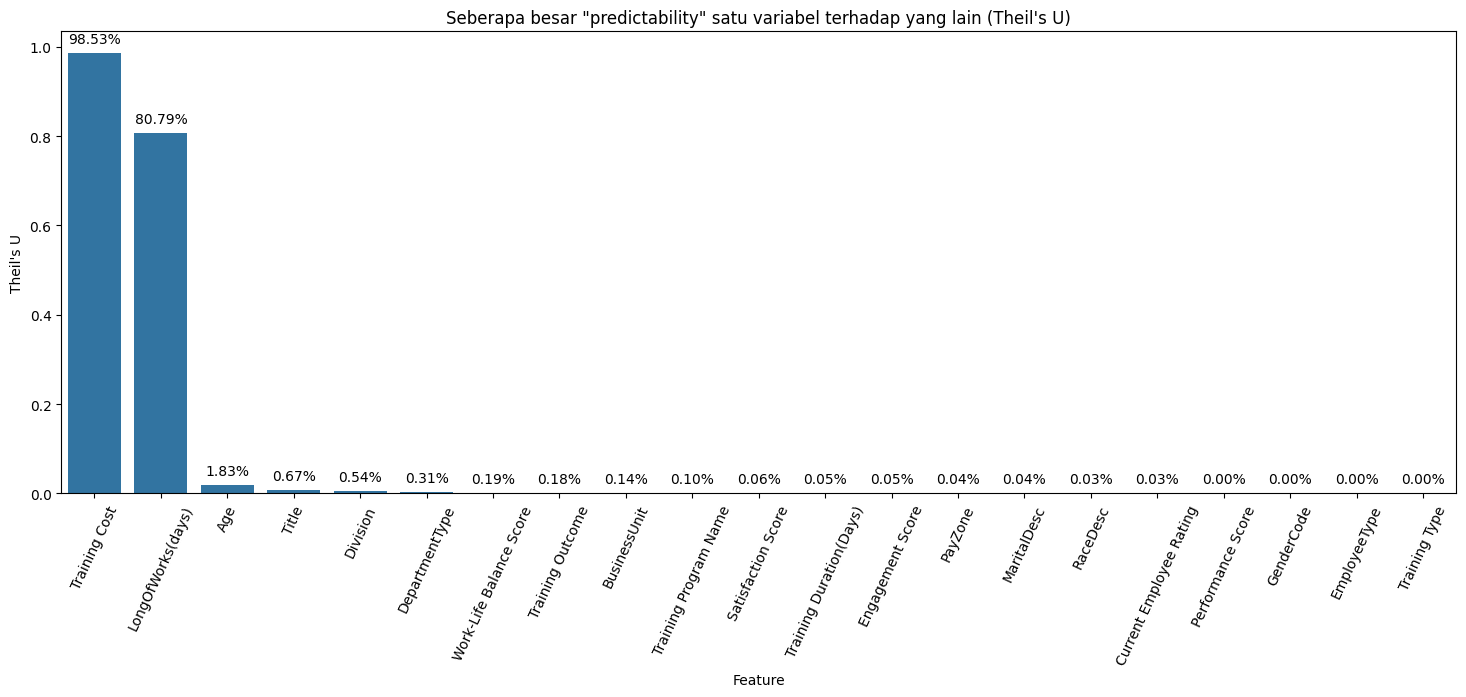

In [834]:
from scipy.stats import entropy

def theils_u(x, y):
    s_xy = pd.crosstab(x, y).values
    p_xy = s_xy / s_xy.sum()
    p_x = p_xy.sum(axis=1)
    p_y = p_xy.sum(axis=0)

    h_y = entropy(p_y)
    h_y_given_x = 0
    for i in range(len(p_x)):
        h_y_given_x += p_x[i] * entropy(p_xy[i] / p_x[i] if p_x[i] > 0 else 0)
    return (h_y - h_y_given_x) / h_y if h_y > 0 else 0

# note: entropy sudah di hitung dari library scipy

results = []

for col in df.drop(columns=["EmployeeStatus"]).columns:
    u = theils_u(df[col], df["EmployeeStatus"])
    results.append({
        'Feature': col,
        "Theil's U": u
    })

# Convert ke dataframe
theils_u_df = pd.DataFrame(results).sort_values("Theil's U", ascending=False)

plt.figure(figsize=(18, 6))
p = sns.barplot(
    data=theils_u_df,
    x="Feature",
    y="Theil's U",
)

for container in p.containers:
  labels = [f"{val*100:.2f}%" for val in container.datavalues]
  p.bar_label(container, labels=labels, label_type="edge", color="black", padding=5)

plt.title("Seberapa besar \"predictability\" satu variabel terhadap yang lain (Theil's U)")
plt.xticks(rotation=65)
plt.show()

### Encoding<br>
Karena banyaknya data kategori kita, maka kita akan menggunakan LabelEncoders agar nilai-nilai kategori menjadi angka

In [835]:
from sklearn.preprocessing import LabelEncoder

encoders = dict()
df_enc = df.copy()

for col in cat_cols:
  le = LabelEncoder()
  encoders[col] = le
  cat_encoded = le.fit_transform(df_enc[col])
  df_enc[col] = cat_encoded

# Lihat perubahannya
df_enc[cat_cols].head().style.set_properties(**df_style).set_table_styles(table_style)

,Title,BusinessUnit,EmployeeStatus,EmployeeType,PayZone,DepartmentType,Division,GenderCode,RaceDesc,MaritalDesc,Performance Score,Training Program Name,Training Type,Training Outcome
0,21,1,0,0,2,3,8,0,4,3,1,2,1,0
1,21,2,0,0,0,3,0,1,2,3,1,1,0,0
2,2,5,0,1,1,4,11,1,2,3,1,2,0,0
3,2,1,0,0,0,4,8,1,3,2,1,3,0,1
4,2,8,0,0,0,4,9,0,3,1,1,4,0,0


#### Membuat reverse encoders agar mampermudahkan nanti saat predict atau membuat GUI

In [836]:
import json

reverse_encoders = dict()

for col in cat_cols:
  le = encoders[col]
  mapping = dict(zip(le.classes_, le.transform(le.classes_)))

  reverse_encoders[col] = mapping

clean_reverse_encoders = dict()

for col in reverse_encoders:
  clean_reverse_encoders[col] = {k: int(v) for k, v in reverse_encoders[col].items()}

print(json.dumps(clean_reverse_encoders, indent=2))

{
  "Title": {
    "Accountant I": 0,
    "Administrative Assistant": 1,
    "Area Sales Manager": 2,
    "BI Developer": 3,
    "BI Director": 4,
    "CIO": 5,
    "Data Analyst": 6,
    "Data Architect": 7,
    "Database Administrator": 8,
    "Director of Operations": 9,
    "Director of Sales": 10,
    "Enterprise Architect": 11,
    "IT Director": 12,
    "IT Manager - DB": 13,
    "IT Manager - Infra": 14,
    "IT Manager - Support": 15,
    "IT Support": 16,
    "Network Engineer": 17,
    "President & CEO": 18,
    "Principal Data Architect": 19,
    "Production Manager": 20,
    "Production Technician I": 21,
    "Production Technician II": 22,
    "Sales Manager": 23,
    "Senior BI Developer": 24,
    "Shared Services Manager": 25,
    "Software Engineer": 26,
    "Software Engineering Manager": 27,
    "Sr. Accountant": 28,
    "Sr. DBA": 29,
    "Sr. Network Engineer": 30
  },
  "BusinessUnit": {
    "BPC": 0,
    "CCDR": 1,
    "EW": 2,
    "MSC": 3,
    "NEL": 4,
    "PL

### Melihat korelasi numerik / semua

#### Mutual Information (MI)<br>
Berguna untuk mengukur seberapa banyak informasi yang dibagikan antara dua variabel (kategori vs kategori dan kategori vs numerik.).

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)


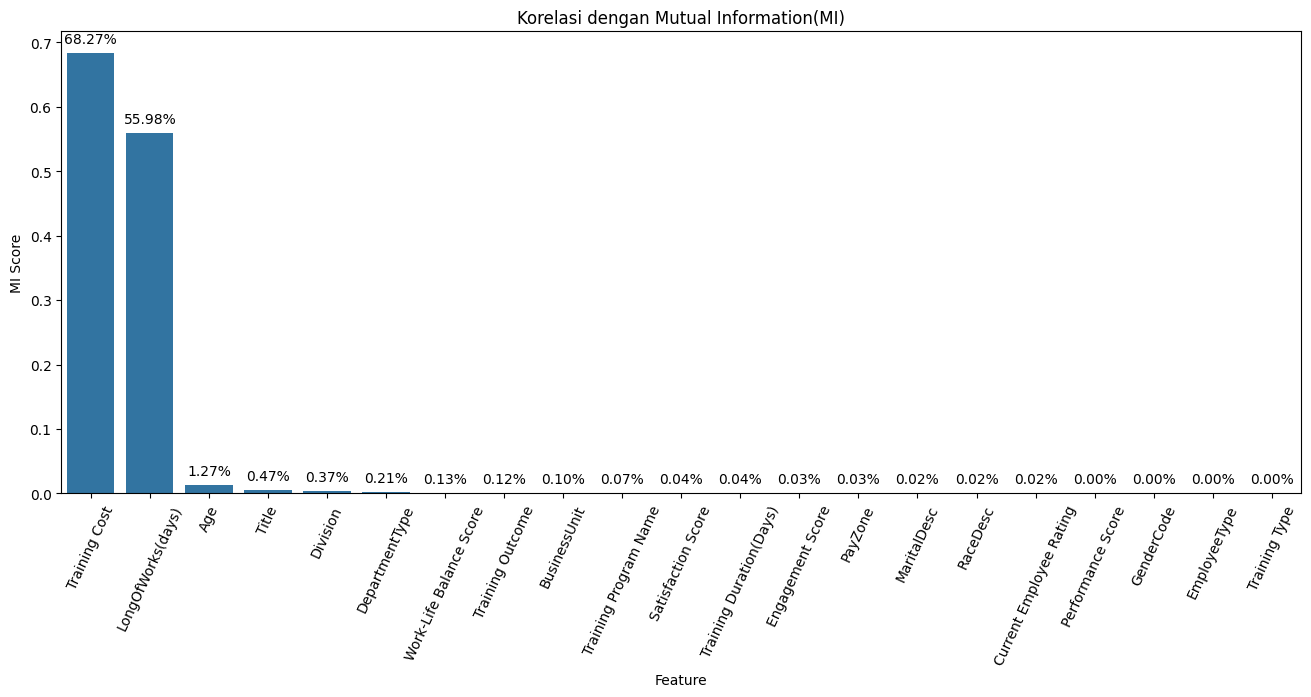

In [837]:
from sklearn.feature_selection import mutual_info_classif

X = df_enc.drop('EmployeeStatus', axis=1)
y = df_enc['EmployeeStatus']

mi = mutual_info_classif(X, y, discrete_features=True)

mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi})
data = mi_df.sort_values('MI Score', ascending=False)

plt.figure(figsize=(16, 6))
p = sns.barplot(
    data=data,
    x="Feature",
    y="MI Score"
)

for container in p.containers:
  labels = [f"{val*100:.2f}%" for val in container.datavalues]
  p.bar_label(container, labels=labels, label_type="edge", color="black", padding=5)

plt.title("Korelasi dengan Mutual Information(MI)")
plt.xticks(rotation=65)
plt.show()

#### Point-Biserial Correlation<br>
- Cocok untuk numerik vs binari.
- Ini sebenarnya varian dari Pearson, tapi untuk target biner.

Rumus:
$$r_{pb} = \frac{\bar{x_0} - \bar{x_1}}{SD_x} \cdot \sqrt{\frac{n_0 \cdot n_1}{n^2}}$$

Keterangan:<br>
- 0 adalah orang yang berhasil dan 1 adalah orang yang gagal<br>
- $\bar{x_0} - \bar{x_1}$ adalah rata-rata dari orang yang gagal dan berhasil<br>
- $n_0 \cdot n_1$ adalah orang yang berhasil di kali orang yang gagal
- $n^2$ adalah jumlah semua orang yang gagal dan berhasil
- $SD_x$ adalah standard deviation $SD = \frac{\sum_{i=1}^{n}(X_i - \bar{X})^2}{n-1}$

In [838]:
def calc_point_biserial(X0, X1):
  X = np.concatenate([X0, X1])

  mean0 = np.mean(X0)
  mean1 = np.mean(X1)
  sd = np.std(X, ddof=1)

  n0 = len(X0)
  n1 = len(X1)
  n = n0 + n1

  if sd == 0 or n == 0:
    return 0

  return ((mean0 - mean1) / sd) * np.sqrt((n0 * n1) / n**2)

results = []

for col in df_enc.columns:
  X0 = df_enc[df_enc["EmployeeStatus"] == 1][col]
  X1 = df_enc[df_enc["EmployeeStatus"] == 0][col]

  pb = calc_point_biserial(X0, X1)
  results.append({
      "Feature": col,
      "Point-Biserial": pb
  })

point_biserial = pd.DataFrame(results).sort_values("Point-Biserial", ascending=False)

##### Visualization

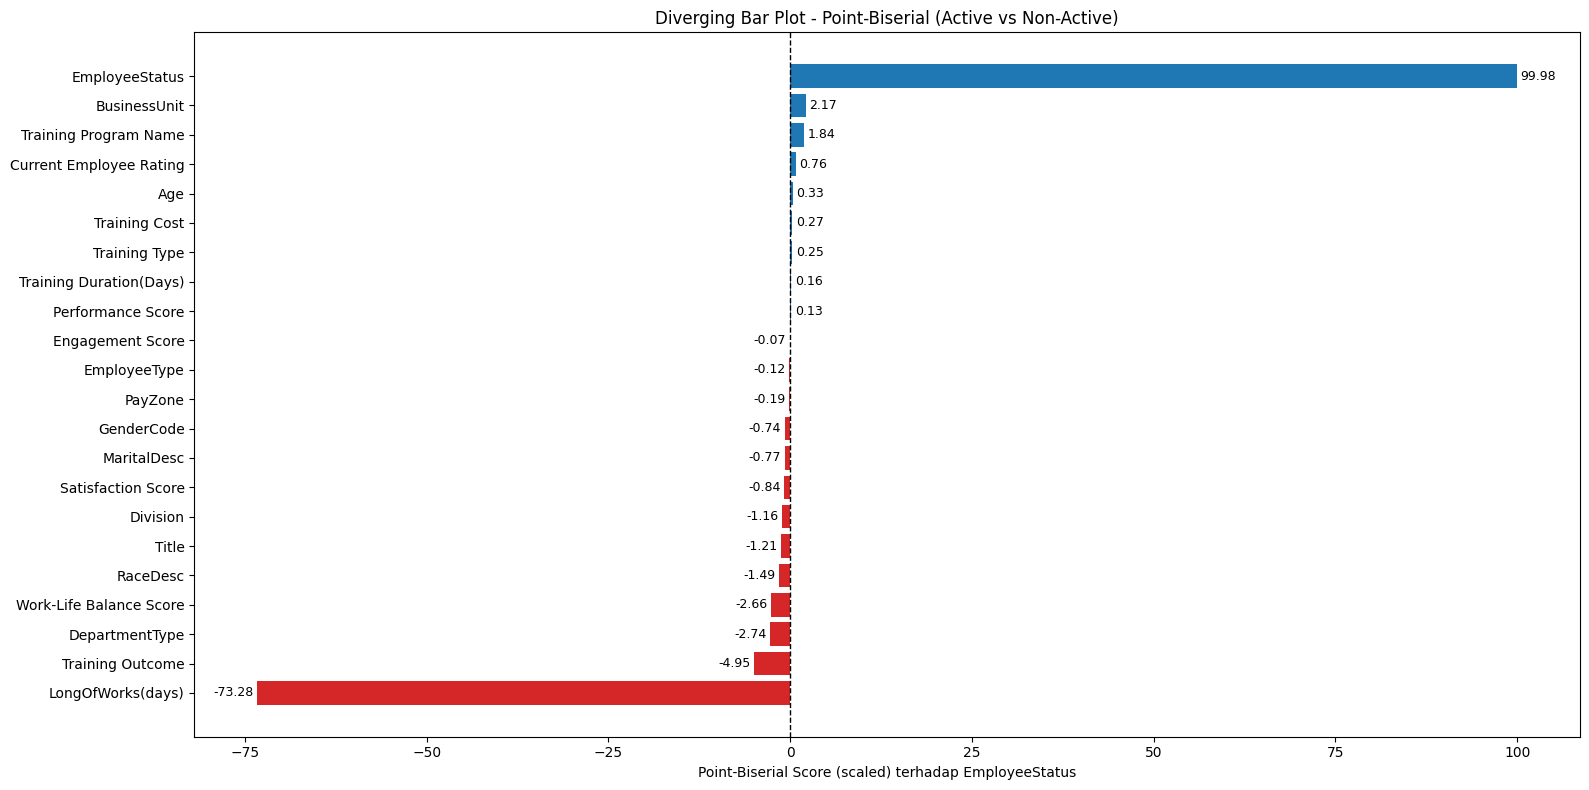

In [839]:
point_biserial["Category"] = ["Active" if x > 0 else "Non-Active" for x in point_biserial["Point-Biserial"]]
point_biserial["Scaled"] = point_biserial["Point-Biserial"] * 100
point_biserial = point_biserial.sort_values("Scaled")

# Diverging Dot Plot
plt.figure(figsize=(16, 8))
colors = {'Active': '#1f77b4', 'Non-Active': '#d62728'}

for idx, row in point_biserial.iterrows():
    plt.barh(row["Feature"], row["Scaled"], color=colors[row["Category"]])
    plt.text(
        row["Scaled"] + (0.5 if row["Scaled"] > 0 else -0.5),
        row["Feature"],
        f'{row["Point-Biserial"]*100:.2f}',
        va='center',
        ha='left' if row["Scaled"] > 0 else 'right',
        color='black',
        fontsize=9)

plt.axvline(0, color='black', linestyle='--', lw=1)

plt.title("Diverging Bar Plot - Point-Biserial (Active vs Non-Active)")
plt.xlabel("Point-Biserial Score (scaled) terhadap EmployeeStatus")
plt.tight_layout()
plt.show()

Cara membacanya mirip seperti di heatmap, manakah variabel yang paling berpengaruh baik secara positif maupun negatif.<br>
Note: EmployeeStatus saya ikutkan untuk sebagai bukti berhasil tidaknya rumus dan sebagai penyeimbang chart.

#### Melihat semua korelasi

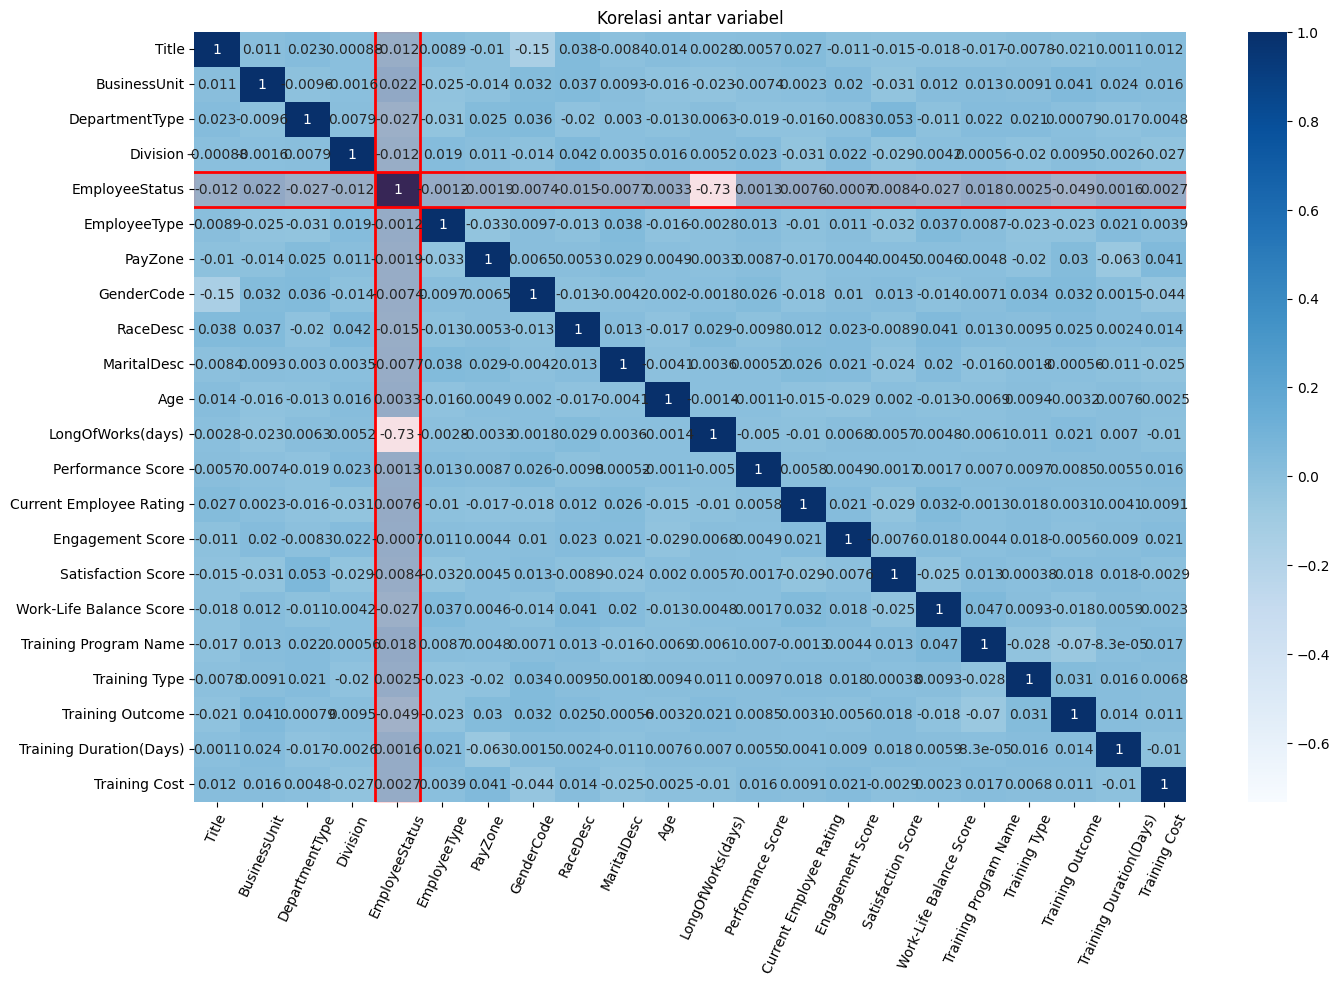

In [840]:
plt.figure(figsize=(16, 10))
plt.title("Korelasi antar variabel")

corr = df_enc.corr()
idx = list(corr.columns).index("EmployeeStatus")

sns.heatmap(corr, annot=True, cmap="Blues")

# Highlight vertikal
plt.axvline(idx, color='red', linewidth=2)
plt.axvline(idx + 1, color='red', linewidth=2)
plt.fill_betweenx(y=[0, corr.shape[0]], x1=idx, x2=idx + 1, color='red', alpha=0.1)

# Highlight horizontal
plt.axhline(idx, color='red', linewidth=2)
plt.axhline(idx + 1, color='red', linewidth=2)
plt.fill_between(x=[0, corr.shape[1]], y1=idx, y2=idx + 1, color='red', alpha=0.1)

plt.xticks(rotation=65)
plt.show()

Hasil korelasi di atas menunjukkan bahwa hanya 1 feature yang berkorelasi, namun tidak apa-apa karena di bawah masih ada beberapa teknik untuk menjadi feature yang signifikan dan kuat. Jika masih hanya sedikit yang berkorelasi kita bisa memilihnya manual.

#### AutoML Feature Importance (Tree-based Models)<br>
Sekarang biar lebih fair saya menggunakan model MachineLearning untuk mencari mana fitur yang cocok?

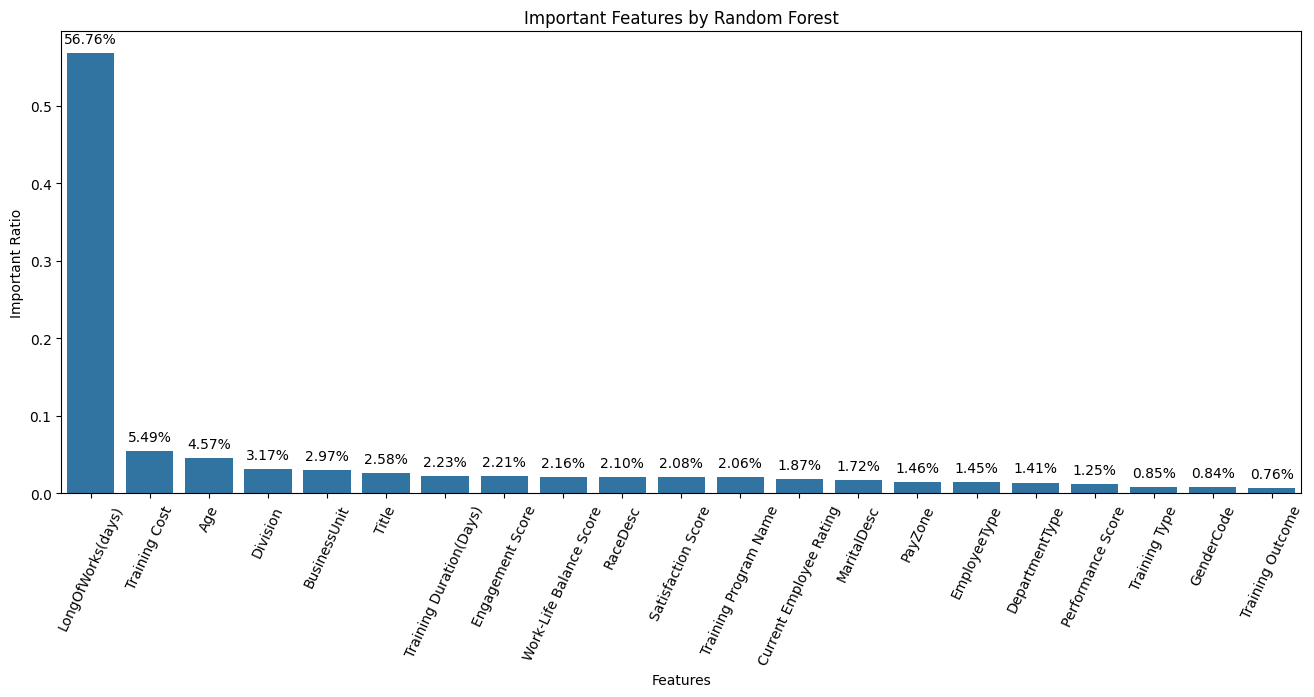

In [841]:
from sklearn.ensemble import RandomForestClassifier

X_dum = df_enc.drop(columns=["EmployeeStatus"])
y_dum = df_enc.EmployeeStatus

# Build model
model = RandomForestClassifier()
model.fit(pd.get_dummies(X_dum), y_dum)
feat_imp = pd.DataFrame({
    "Features": pd.get_dummies(X_dum).columns,
    "Important Ratio": model.feature_importances_
}).sort_values(by="Important Ratio", ascending=False)

# Visualization
plt.figure(figsize=(16, 6))
p = sns.barplot(
    data=feat_imp,
    x="Features",
    y="Important Ratio"
)

for container in p.containers:
  labels = [f"{col*100:.2f}%" for col in container.datavalues]
  p.bar_label(container, label_type="edge", labels=labels, color="black", padding=5)

plt.title("Important Features by Random Forest")
plt.xticks(rotation=65)
plt.show()

### Pemilihan kolom
Berdasarkan melihat data korelasi di atas saya memutuskan untuk memilih kolom yang di perlukan dan tidak, hasil keputusan saya ini berdasarkan cara korelasi di atas dan pemilihan manual.

#### Voting dari semua pemilihan fitur

<ipython-input-842-67130f6faafa>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  p = sns.barplot(y='Feature', x='Total Vote', data=voting, palette="crest")


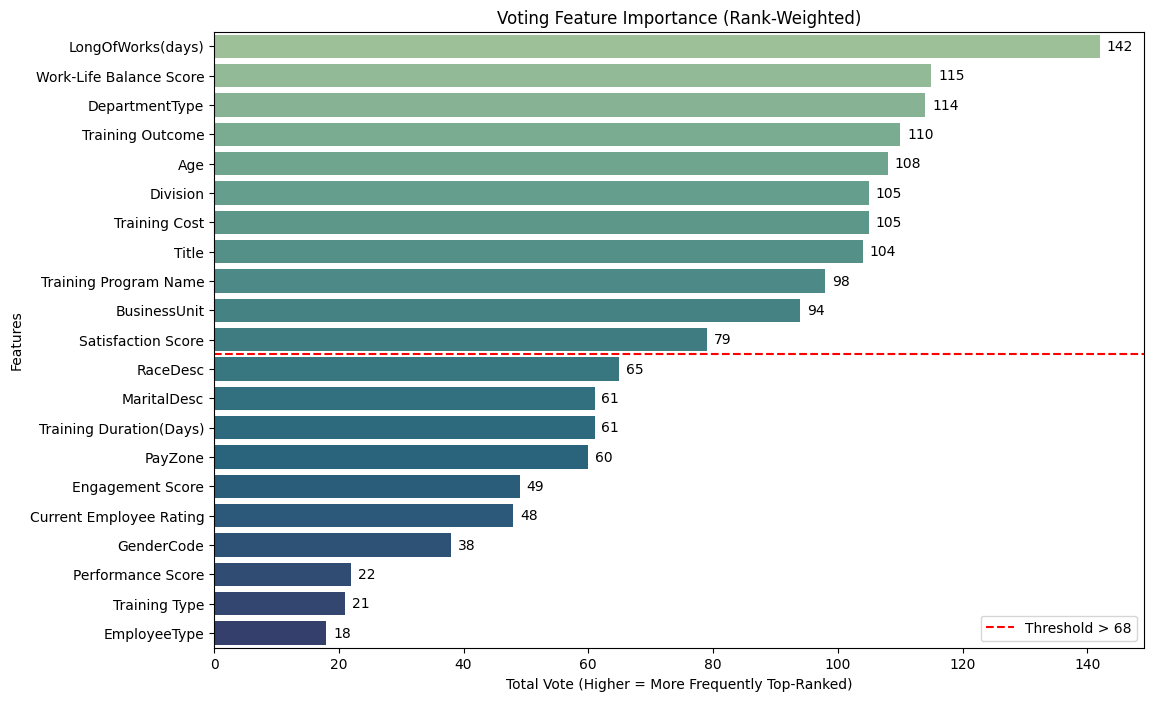

In [842]:
# Chi-Square
feat_by_cs = chi_squared_df.sort_values(by="p-value")["Feature"].values

# Cramér's V
feat_by_cv = cramersv_df["Feature"].values

# Theil's U
feat_by_tu = theils_u_df["Feature"].values

# MI
feat_by_mi = mi_df.sort_values(by="MI Score", ascending=False)["Feature"].values

# Point-Biserial
feat_by_pb = point_biserial[["Feature",	"Point-Biserial"]][point_biserial["Feature"] != "EmployeeStatus"]
feat_by_pb["Point-Biserial"] = abs(point_biserial["Point-Biserial"])
feat_by_pb = feat_by_pb.sort_values(by="Point-Biserial", ascending=False)["Feature"].values

# Semua Korelasi
feat_by_corr = pd.DataFrame({
    "Features": corr.index,
    "Values": abs(corr["EmployeeStatus"])
}).reset_index(drop=True).sort_values(by="Values", ascending=False)
feat_by_corr = feat_by_corr[feat_by_corr["Features"] != "EmployeeStatus"]["Features"].values

# Random Forest
feat_by_RFC = feat_imp["Features"].values


#VOTING
all_methods = [feat_by_cs, feat_by_cv, feat_by_tu, feat_by_mi, feat_by_pb, feat_by_corr, feat_by_RFC]
method_names = ['Chi-Square', 'Cramer V', 'Theil U', 'Mutual Info', 'Point-Biserial', 'Correlation', 'Random Forest']

all_feats = np.concatenate(all_methods)
unique_feats = pd.Series(all_feats).unique()

voting = pd.DataFrame({'Feature': unique_feats})

# Calc Point
for method, name in zip(all_methods, method_names):
    points = {feat: len(method) - rank for rank, feat in enumerate(method)}
    voting[name] = voting['Feature'].map(points).fillna(0)

# Sum point
voting['Total Vote'] = voting[method_names].sum(axis=1)

voting = voting.sort_values(by='Total Vote', ascending=False)

# Visualization
plt.figure(figsize=(12, 8))
p = sns.barplot(y='Feature', x='Total Vote', data=voting, palette="crest")

for container in p.containers:
  p.bar_label(container, label_type="edge", color="black", padding=5)

plt.title("Voting Feature Importance (Rank-Weighted)")
plt.axhline(y=np.where(voting["Feature"].unique() == "RaceDesc")[0][0] - 0.5,
            color='red', linestyle='dashed', label="Threshold > 68")
plt.legend()
plt.xlabel("Total Vote (Higher = More Frequently Top-Ranked)")
plt.ylabel("Features")
plt.show()

Berdasarkan hasil voting di atas akan memutuskan untuk memilih fitur > 65

In [843]:
selected_features = voting[voting["Total Vote"] > 68]["Feature"].reset_index(drop=True)
selected_features.index = selected_features.index + 1
selected_features.to_frame().T.style.set_properties(**df_style).set_table_styles(table_style)

,1,2,3,4,5,6,7,8,9,10,11
Feature,LongOfWorks(days),Work-Life Balance Score,DepartmentType,Training Outcome,Age,Division,Training Cost,Title,Training Program Name,BusinessUnit,Satisfaction Score


## Splitting datasets

In [844]:
# Membuat fungsi splitting
def train_test_split(X, y, test_size=0.2, random_state=None):
  if random_state:
    np.random.seed(random_state)

  n_samples = len(X)

  shuffle_indices = np.random.permutation(np.arange(n_samples))

  test_size = round(test_size * n_samples)
  train_size = n_samples - test_size

  train_indices = shuffle_indices[:train_size]
  test_indices = shuffle_indices[test_size:]

  X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
  y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

  return [X_train, X_test, y_train, y_test]


X = df_enc[selected_features]
y = df_enc["EmployeeStatus"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Selection Model

### Modeling

In [845]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

pipelines = {}

for name, model in models.items():
  # Model di bawah perlu scaling untuk hasil optimal
    if name in ["SVM", "KNN", "Logistic Regression"]:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipe = Pipeline([
            ('model', model)
        ])
    pipelines[name] = pipe

### Evaluation

#### Membangun Classification Report<br>
Berguna untuk mengukur pemahaman saya dalam evaluasi model klasifikasi

##### __Accuracy__<br>
Matrix evaluation yang digunakan untuk menghitung prensentase prediksi yang benar terdapat seluruh data.

Rumusnya:
$$A = \frac{TP + TN}{TP + TN + FP + FN}$$

Atau sederhananya:
$$A = \frac{\text{total_benar}}{\text{total_sampel}}$$

In [846]:
def calc_accuracy(y_true, y_pred):
  return np.sum(y_true == y_pred) / len(y_pred)

##### __Precision__<br>
Digunakan untuk mengukur seberapa banyak prediksi positif yang benar dibandingkan semua prediksi positif.

Rumusnya:
$$P_i = \frac{TP}{TP + FP}$$

In [847]:
def calc_precision(TP, FP):
  return TP / (TP + FP) if (TP + FP) != 0 else 0

##### __Recall__<br>
Digunakan untuk mengukur seberapa banyak data positif yang berhasil diprediksi dibandingkan total data sebenarnya.

Rumusnya:
$$R_i = \frac{TP}{TP + FN}$$

In [848]:
def calc_recall(TP, FN):
  return TP / (TP + FN) if (TP + FN) != 0 else 0

##### __F1-Score__<br>
Digunakan untuk menghitung rata-rata nilai harmonis antara precision dan recal.

Rumusnya:
$$F1_i = 2 \cdot \frac{P_{i}R_{i}}{P_i + R_i}$$

In [849]:
def calc_f1_score(TP, FP, FN):
  P = calc_precision(TP, FP)
  R = calc_recall(TP, FN)
  return 2 * ((P * R) / (P + R)) if (P + R) != 0 else 0

#### __Support__<br>
Support sebenarnya bukanlah matrix evaluation namun hanya menghitung berapa jumlah sampel disetiap matrix evaluation.

In [850]:
def calc_sample(y_true, cat):
  return np.sum(y_true == cat)

##### __Macro Avg__<br>
Macro Avg juga bukanlah sebuah matrixs evaluation namun menghitung rata-rata dari semua kategori __tanpa memperhatikan jumlah sampel__ di tiap kategori.

Rumusnya:
$$MA = \frac{\sum \text{matrix_perkelas}}{\text{jumlah_kelas}}$$

In [851]:
def calc_macro_avg(matrixs):
  return np.mean(matrixs, axis=0)

##### __Weighted Avg__<br>
Juga bukan matrix evaluation namun berguna untuk menghitung rata-rata dari semua kategori dengan memperhatikan jumlah sampel di tiap kategori.

Rumusnya:
$$WA = \frac{\sum(\text{matrix_perkelas} \cdot \text{support})}{\text{jumlah_support}}$$

In [852]:
def calc_weighted_avg(matrixs, supports):
  supports = np.array(supports)
  return np.sum(matrixs * supports[0:, None], axis=0) / np.sum(supports)

##### Gabungkan menjadi classification report

In [853]:
def my_classification_report(y_true, y_pred):
  if len(np.unique(y_true)) != len(np.unique(y_pred)):
    raise ValueError("y_true and y_pred must be same unique categories")

  cats = np.unique(y_true)
  reports = {"Category": [], "Precision": [], "Recall": [], "F1-Score": [], "Support": []}

  total_TP_TN = 0

  for cat in cats:
    # Confusion Matrixs
    TP = np.sum((y_true == cat) & (y_pred == cat))
    TN = np.sum((y_true != cat) & (y_pred != cat))
    FP = np.sum((y_true != cat) & (y_pred == cat))
    FN = np.sum((y_true == cat) & (y_pred != cat))

    # Calculation Matrixs
    P = calc_precision(TP, FP)
    R = calc_recall(TP, FN)
    F1 = calc_f1_score(TP, FP, FN)
    support = calc_sample(y_true, cat)

    # Store Matrixs
    reports["Category"].append(cat)
    reports["Precision"].append(P)
    reports["Recall"].append(R)
    reports["F1-Score"].append(F1)
    reports["Support"].append(calc_sample(y_true, cat))

    total_TP_TN += TP + TN

  accuracy = calc_accuracy(y_true, y_pred)
  reports["Accuracy"] = [accuracy] * len(cats)

  # Cacl macro * weight
  matrixs = np.array([reports["Precision"], reports["Recall"], reports["F1-Score"]]).T
  supports = reports["Support"]
  macro_avg = ["Macro Avg", *calc_macro_avg(matrixs), np.sum(supports), accuracy]
  weighted_avg = ["Weighted Avg", *calc_weighted_avg(matrixs, supports), np.sum(supports), accuracy]

  # to dataframe
  reports_df = pd.DataFrame(reports, columns=["Category", "Precision", "Recall", "F1-Score", "Support", "Accuracy"])
  reports_df.loc[len(reports_df)] = macro_avg
  reports_df.loc[len(reports_df)] = weighted_avg

  return reports_df

### Training

In [854]:
reports = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    reports[name] = my_classification_report(y_test, y_pred)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:20:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


#### Model Reports

In [855]:
from IPython.display import Markdown

for name, df in reports.items():
    df_no_accuracy = df.drop(columns=["Accuracy"])

    # Tampilkan tabel tanpa kolom 'accuracy'
    display(
        df_no_accuracy
        .style.set_properties(**df_style)
        .set_table_styles(table_style)
        .set_caption(f"{name} Classification Report")
    )

    accuracy_value = df["Accuracy"][0]
    display(Markdown(f"Accuracy: **{accuracy_value*100:.2f}%**"))

,Category,Precision,Recall,F1-Score,Support
0,0,0.839192,0.806588,0.822567,1184
1,1,0.818542,0.849507,0.833737,1216
2,Macro Avg,0.828867,0.828047,0.828152,2400
3,Weighted Avg,0.828729,0.828333,0.828226,2400


Accuracy: **82.83%**

,Category,Precision,Recall,F1-Score,Support
0,0,0.942229,0.978041,0.959801,1184
1,1,0.977797,0.941612,0.959363,1216
2,Macro Avg,0.960013,0.959826,0.959582,2400
3,Weighted Avg,0.960250,0.959583,0.959579,2400


Accuracy: **95.96%**

,Category,Precision,Recall,F1-Score,Support
0,0,0.859560,0.858108,0.858833,1184
1,1,0.862069,0.863487,0.862777,1216
2,Macro Avg,0.860815,0.860797,0.860805,2400
3,Weighted Avg,0.860831,0.860833,0.860832,2400


Accuracy: **86.08%**

,Category,Precision,Recall,F1-Score,Support
0,0,0.839965,0.820101,0.829915,1184
1,1,0.828778,0.847862,0.838211,1216
2,Macro Avg,0.834372,0.833982,0.834063,2400
3,Weighted Avg,0.834297,0.834167,0.834118,2400


Accuracy: **83.42%**

,Category,Precision,Recall,F1-Score,Support
0,0,0.949209,0.962838,0.955975,1184
1,1,0.963303,0.949836,0.956522,1216
2,Macro Avg,0.956256,0.956337,0.956248,2400
3,Weighted Avg,0.956350,0.956250,0.956252,2400


Accuracy: **95.62%**

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

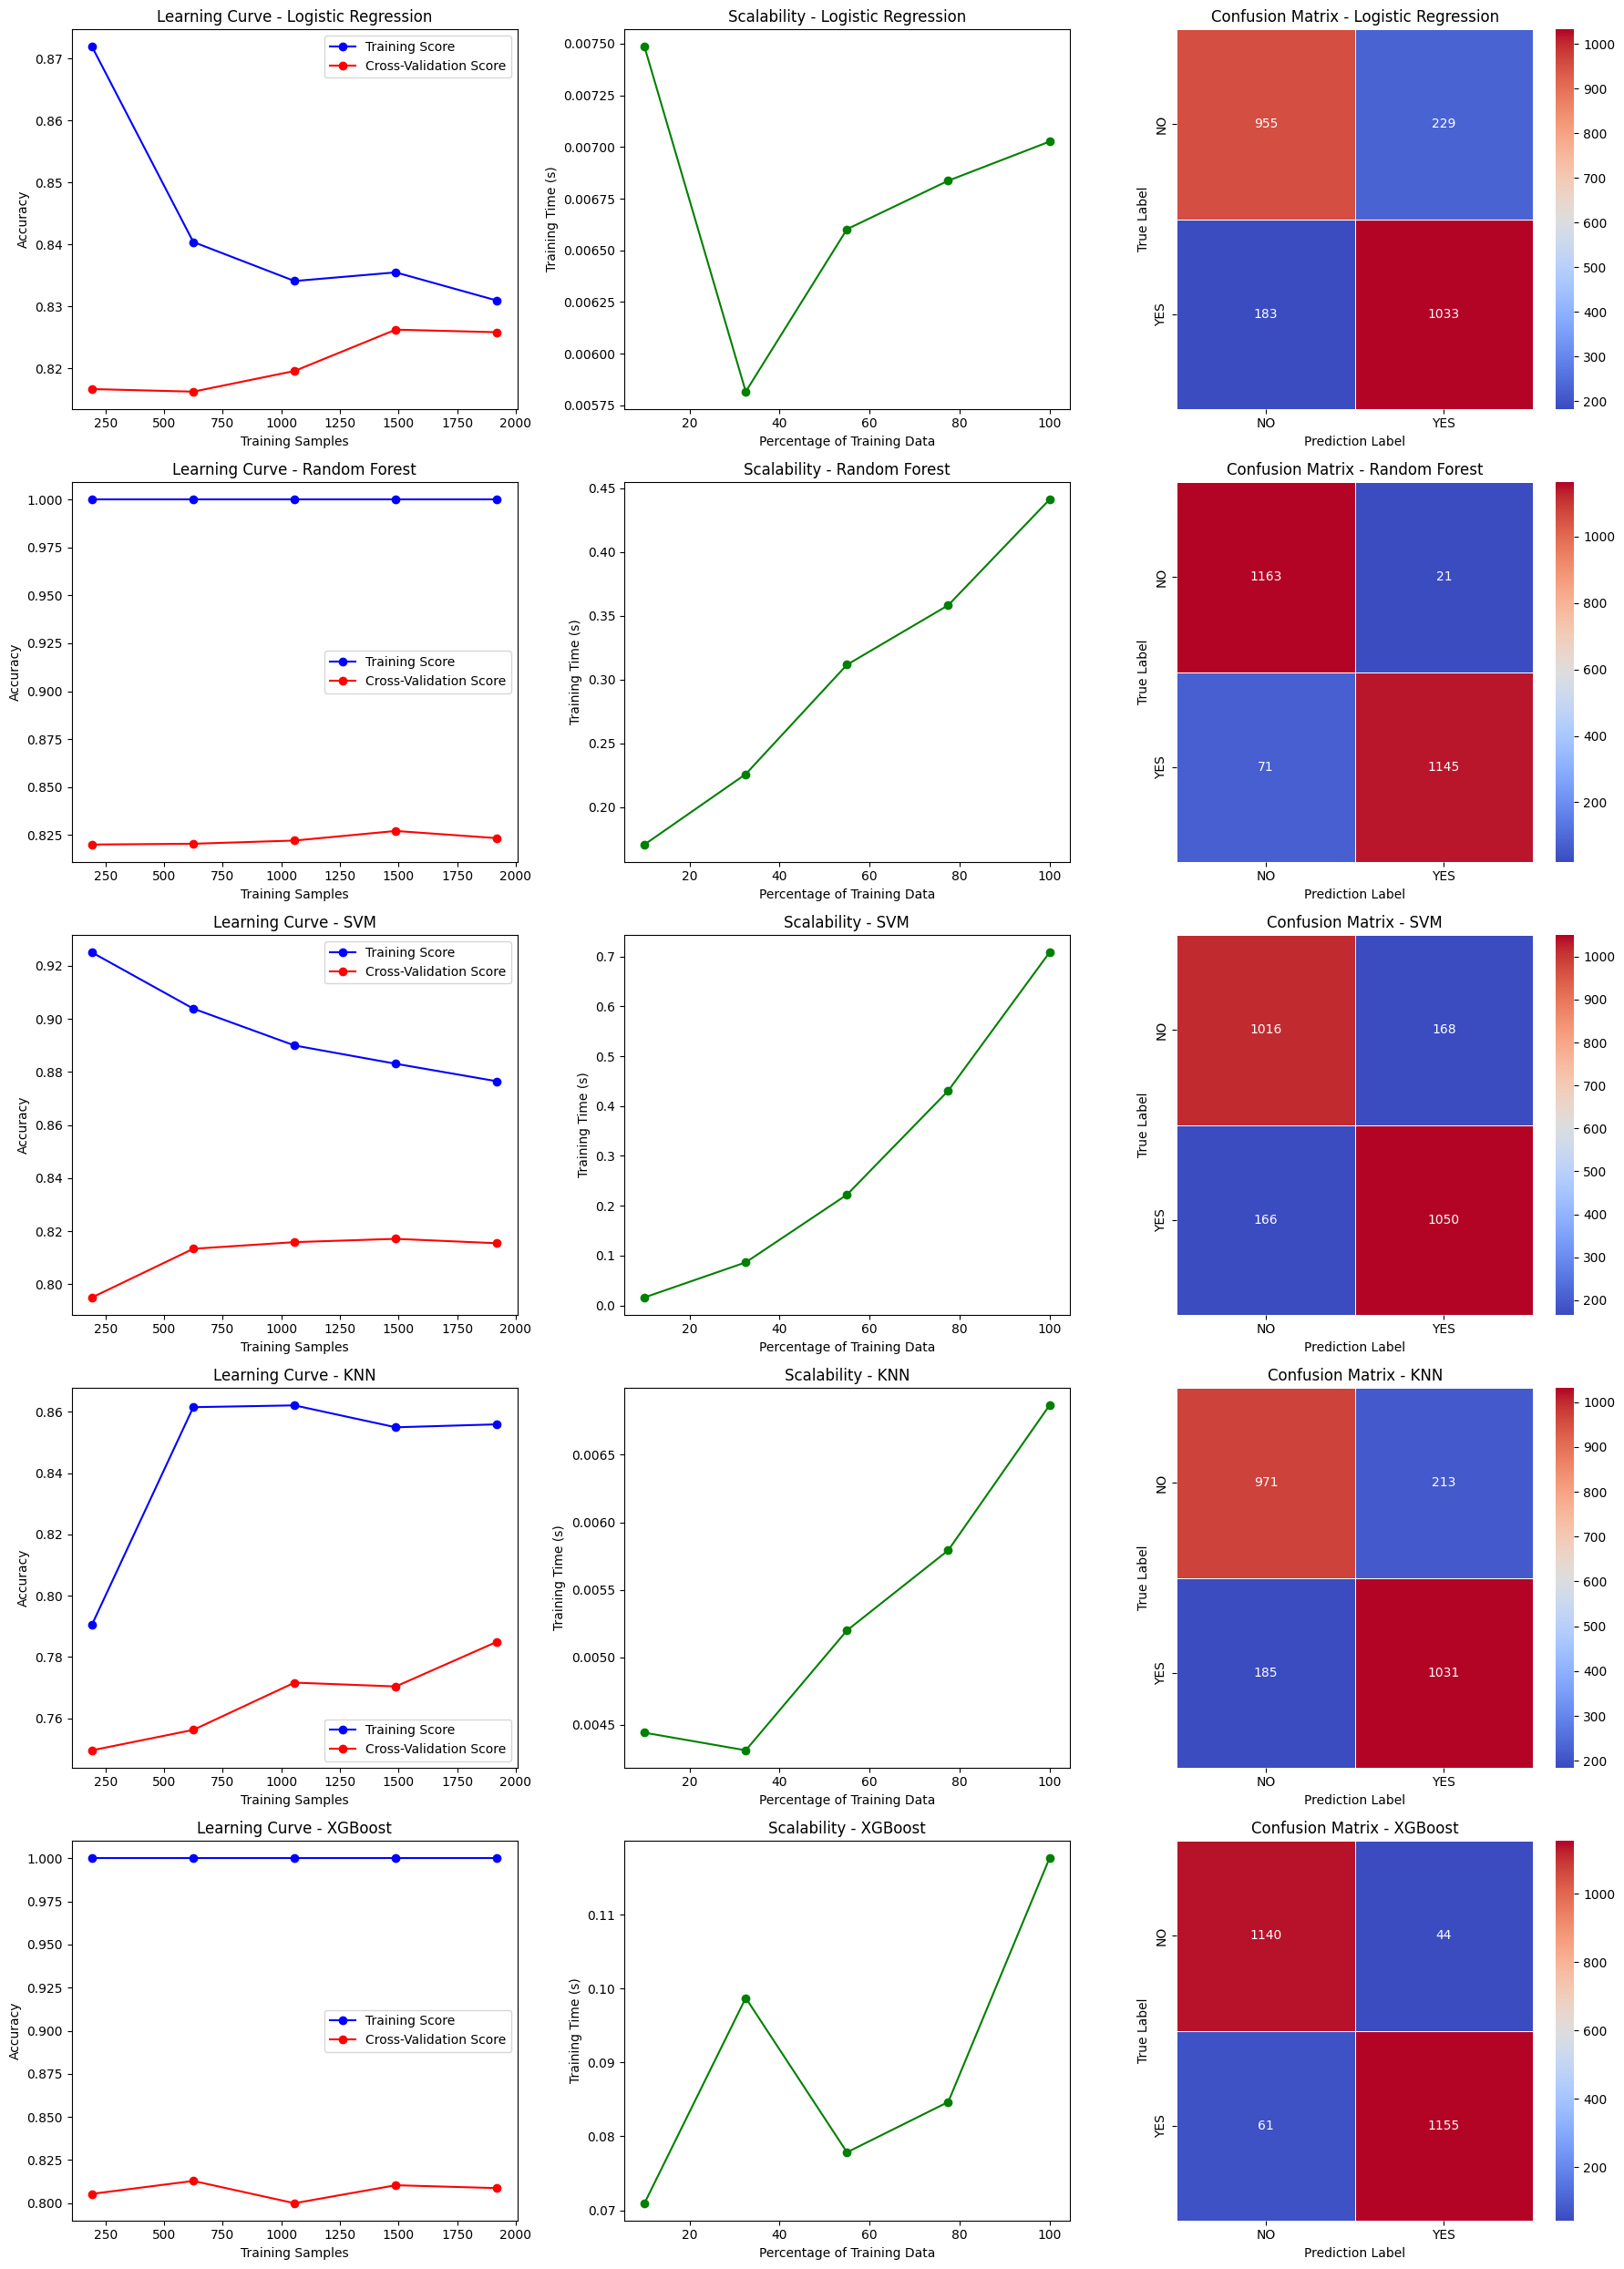

In [856]:
import time
from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(len(models), 3, figsize=(18, len(models) * 5))

for i, (name, pipe) in enumerate(pipelines.items()):
    # ===== Learning Curve =====
    train_sizes, train_scores, test_scores = learning_curve(
        pipe, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    axes[i, 0].plot(train_sizes, train_mean, 'o-', label="Training Score", color="blue")
    axes[i, 0].plot(train_sizes, test_mean, 'o-', label="Cross-Validation Score", color="red")
    axes[i, 0].set_title(f"Learning Curve - {name}")
    axes[i, 0].set_xlabel("Training Samples")
    axes[i, 0].set_ylabel("Accuracy")
    axes[i, 0].legend()

    # ===== Scalability (Training Time) =====
    sizes = np.linspace(0.1, 1.0, 5)
    train_times = []

    for size in sizes:
        X_train_subset = X_train[:int(size * len(X_train))]
        y_train_subset = y_train[:int(size * len(y_train))]

        start_time = time.time()
        pipe.fit(X_train_subset, y_train_subset)
        train_times.append(time.time() - start_time)

    axes[i, 1].plot(sizes * 100, train_times, marker="o", linestyle="-", color="green")
    axes[i, 1].set_title(f"Scalability - {name}")
    axes[i, 1].set_xlabel("Percentage of Training Data")
    axes[i, 1].set_ylabel("Training Time (s)")

 # ===== Performance Metrics (Confusion Matrix) =====
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        cmap="coolwarm",
        linewidths=0.5,
        fmt="d",
        xticklabels=["NO", "YES"],
        yticklabels=["NO", "YES"],
        ax=axes[i, 2]
    )

    axes[i, 2].set_title(f"Confusion Matrix - {name}")
    axes[i, 2].set_xlabel("Prediction Label")
    axes[i, 2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

Pada list tabel di atas model dengan tingkat akurasi yang tinggi di dapatkan oleh model RandomForest dan XGBoost.

## Mencoba menggunakan DeepLearning<br>
Selain saya memiliki pemahaman di Machine Learning saya juga memiliki pemahaman juga di DeepLearning, contoh simpelnya adalah model DeepLearning FNN(Feedforward Neural Network)/MLP(Multi-Layer Perceptron).

In [857]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Activation
from keras.optimizers import Adam

model_dl = Sequential([
    Dense(128, input_shape=(len(selected_features), )),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(64, "relu",),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(32, "relu",),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.2),

    Dense(1, "sigmoid")
])

model_dl.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
model_dl.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                     │ (None, 128)                 │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_27               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_27 (Activation)           │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_28               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_28 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_29 (Activation)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,801 (50.00 KB)

 Trainable params: 12,353 (48.25 KB)

 Non-trainable params: 448 (1.75 KB)

#### Training model DL

In [858]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.callbacks import Callback

train_scaler = StandardScaler()
X_train_scaled = train_scaler.fit_transform(X_train)

test_scaler = StandardScaler()
X_test_scaled = train_scaler.fit_transform(X_test)

X_train_tensor_keras = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
y_train_tensor_keras = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_test_tensor_keras = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_test_tensor_keras = tf.convert_to_tensor(y_test, dtype=tf.float32)

class StopAtAccuracy(Callback):
    def __init__(self, threshold=0.91):
        super(StopAtAccuracy, self).__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        if logs is not None and logs.get("accuracy") >= self.threshold:
            print(f"\nStopping training: accuracy has reached {logs['accuracy']:.4f}")
            self.model.stop_training = True

stop_acc = StopAtAccuracy(threshold=0.91)

history = model_dl.fit(
    X_train_tensor_keras,
    y_train_tensor_keras,
    validation_data=(X_test_tensor_keras, y_test_tensor_keras),
    epochs=300,
    callbacks=[stop_acc])

Epoch 1/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5708 - loss: 0.7238 - val_accuracy: 0.7875 - val_loss: 0.6197
Epoch 2/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7764 - loss: 0.4773 - val_accuracy: 0.8233 - val_loss: 0.5042
Epoch 3/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7962 - loss: 0.4308 - val_accuracy: 0.8379 - val_loss: 0.4046
Epoch 4/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8054 - loss: 0.3927 - val_accuracy: 0.8400 - val_loss: 0.3441
Epoch 5/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8083 - loss: 0.3867 - val_accuracy: 0.8417 - val_loss: 0.3271
Epoch 6/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8080 - loss: 0.3790 - val_accuracy: 0.8450 - val_loss: 0.3163
Epoch 7/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8110 - loss: 0.3801 - val_accuracy: 0.8458 - val_loss: 0.3129
Epoch 8/300
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8207 - loss: 0.3642 - val_accuracy: 0.8462 

#### Evaluation

In [859]:
X_test_scaled = train_scaler.fit_transform(X_test)

y_pred_dl = model_dl.predict(X_test_scaled)

report_model_dl = my_classification_report(y_test, y_pred_dl.round().flatten())

df_no_accuracy = report_model_dl.drop(columns=["Accuracy"])

display(
    df_no_accuracy
    .style.set_properties(**df_style)
    .set_table_styles(table_style)
    .set_caption(f"DeepLearning Classification Report")
)

accuracy_value = report_model_dl["Accuracy"][0]
display(Markdown(f"Accuracy: **{accuracy_value*100:.2f}%**"))

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Category,Precision,Recall,F1-Score,Support
0,0,0.913149,0.950169,0.931291,1184
1,1,0.949486,0.912007,0.930369,1216
2,Macro Avg,0.931318,0.931088,0.930830,2400
3,Weighted Avg,0.931560,0.930833,0.930824,2400


Accuracy: **93.08%**

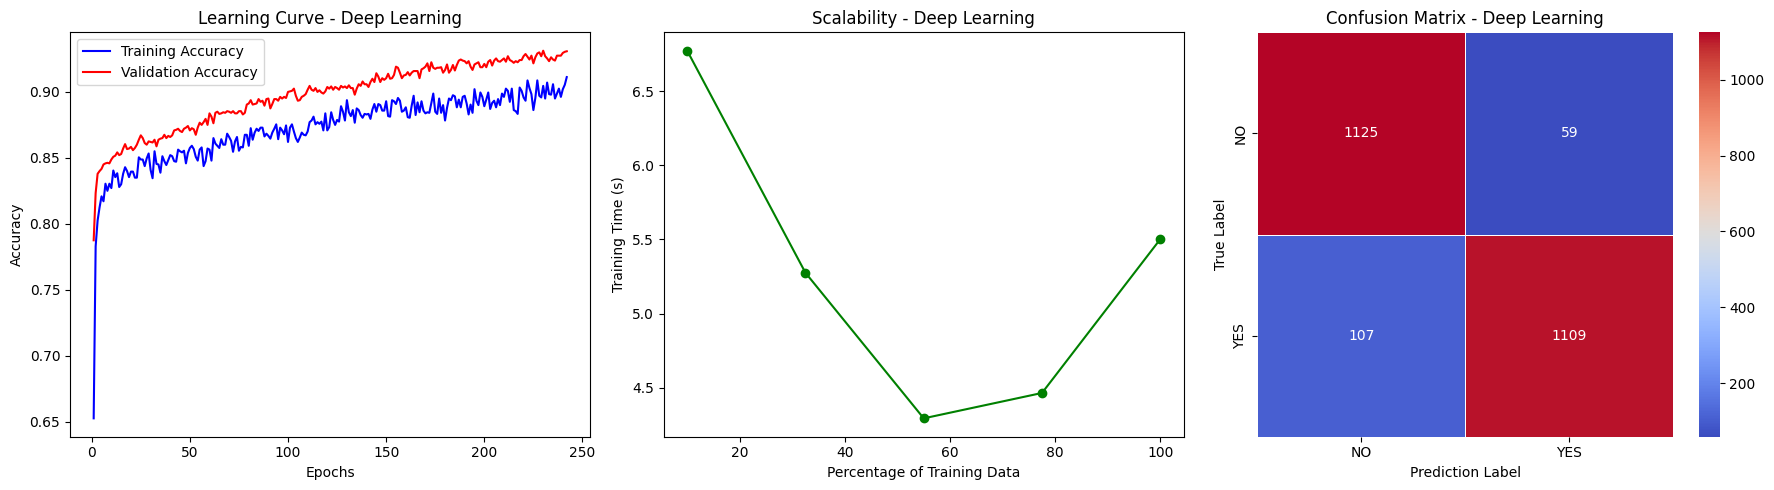

In [862]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ===== Learning Curve (Training Accuracy per Epoch) =====
train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
epochs = range(1, len(train_acc) + 1)

axes[0].plot(epochs, train_acc, label="Training Accuracy", color="blue")
axes[0].plot(epochs, val_acc, label="Validation Accuracy", color="red")
axes[0].set_title("Learning Curve - Deep Learning")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# ===== Scalability (Training Time) =====
sizes = np.linspace(0.1, 1.0, 5)
train_times = []

for size in sizes:
    X_train_subset = X_train_scaled[:int(size * len(X_train))]
    y_train_subset = y_train[:int(size * len(y_train))]

    # Clone model agar bobotnya tetap seperti model asli
    temp_model = tf.keras.models.clone_model(model_dl)
    temp_model.set_weights(model_dl.get_weights())

    temp_model.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

    start_time = time.time()
    temp_model.fit(X_train_subset, y_train_subset, epochs=5, verbose=0, batch_size=32)
    train_times.append(time.time() - start_time)

axes[1].plot(sizes * 100, train_times, marker="o", linestyle="-", color="green")
axes[1].set_title("Scalability - Deep Learning")
axes[1].set_xlabel("Percentage of Training Data")
axes[1].set_ylabel("Training Time (s)")

# ===== Performance Metrics (Confusion Matrix) =====
cm = confusion_matrix(y_test, y_pred_dl.round().flatten())

sns.heatmap(
    cm,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt="d",
    xticklabels=["NO", "YES"],
    yticklabels=["NO", "YES"],
    ax=axes[2]
)

axes[2].set_title("Confusion Matrix - Deep Learning")
axes[2].set_xlabel("Prediction Label")
axes[2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

### Analisis semua model<br>
Untuk mempermudah analisis saya menggunakan matrics accuracy agar fair.

<ipython-input-863-b4d37d7792c2>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  p = sns.barplot(
<ipython-input-863-b4d37d7792c2>:10: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  p = sns.barplot(


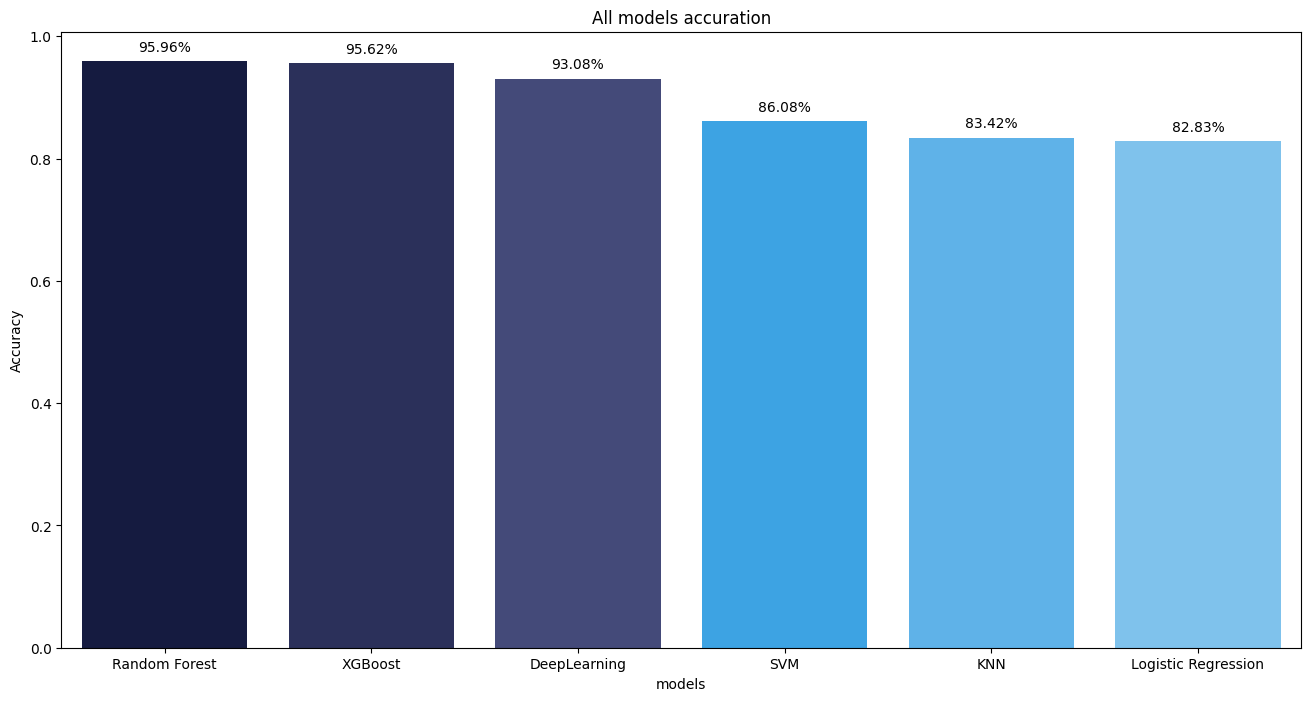

In [863]:
acc_all_model = pd.DataFrame({
    name: acc["Accuracy"][0] for name, acc in reports.items()
}, index=["Accuracy"]).T

acc_all_model.loc["DeepLearning"] = report_model_dl["Accuracy"][0]
acc_all_model = acc_all_model.reset_index(names='models')

# Visualization
plt.figure(figsize=(16, 8))
p = sns.barplot(
    data=acc_all_model.sort_values(by="Accuracy", ascending=False),
    x="models",
    y="Accuracy",
    palette=palatte
)

for container in p.containers:
  labels = [f"{val*100:.2f}%" for val in container.datavalues]
  p.bar_label(container, labels=labels, label_type="edge", color="black", padding=5)

plt.title("All models accuration")
plt.show()

Saya akan memilih model yang paling tinggi yakni "Random Forest"

## Export Model

In [ ]:
import pickle

selected_model = pipelines["Random Forest"]
filename = "random_forest_model.pkl"

# Simpan model
with open(filename, 'wb') as file:
    pickle.dump(selected_model, file)

print(f"Model Random Forest disimpan sebagai {filename}")